# Total Spend Prediction — Regression Modeling

This notebook implements and compares a broad set of regression models to predict **TotalSpend**. Rather than focusing on a single modeling approach, the analysis follows a structured progression across multiple model families in order to evaluate different assumptions, levels of complexity, and inductive biases.

In total, **20 regression models** are trained and evaluated. These models are not random variants, but are intentionally grouped into coherent categories, each serving a specific analytical purpose. Some models act as simple baselines, others explore non-linear feature interactions, and more advanced ensemble methods are included to assess potential performance gains.

The modeling workflow is learning-oriented and exploratory by design. While not all models are intended for final deployment, each contributes to understanding the trade-offs between interpretability, flexibility, and generalization performance. All preprocessing steps are applied in a leakage-safe manner, with parameters fitted exclusively on the training data.

The evaluated models are organized into the following categories:

---

## 1. Linear and Regularized Linear Models (Models 1–6)

This group establishes baseline performance and emphasizes interpretability. It includes ordinary least squares regression and regularized variants designed to address multicollinearity and reduce model complexity.

- Baseline linear regression with different feature sets  
- Ridge regression for coefficient shrinkage  
- Lasso-based models for feature selection and sparsity  
- Linear regression trained on Lasso-selected features  

These models provide a reference point for assessing the added value of more complex approaches.

---

## 2. Polynomial Regression Models (Models 7–11)

Polynomial models extend linear regression by incorporating second-degree feature interactions. Both full and regularized variants are explored to balance expressive power and overfitting risk.

- Polynomial linear regression (degree 2)  
- Polynomial Ridge and Lasso models  
- Feature-selected polynomial models  

This group evaluates whether non-linear relationships substantially improve predictive performance.

---

## 3. Decision Tree Models (Models 12–15)

Single regression trees are used to capture complex non-linear patterns without explicit feature transformations.

- Fully grown regression tree (overfitting reference)  
- Hyperparameter-tuned regression tree  
- Cost-complexity pruned trees  

These models illustrate the trade-off between model flexibility and generalization.

---

## 4. Ensemble Tree-Based Models (Models 16–19)

Ensemble methods combine multiple decision trees to improve robustness and predictive accuracy.

- Random Forest (baseline and tuned)  
- Gradient Boosting regression  
- Tuned XGBoost regressor  

These models represent the most flexible and high-performing approaches evaluated in this notebook.

---

## 5. Kernel-Based Model (Model 20-21)

Support Vector Regression (SVR) with an RBF kernel is included as a distance-based, non-linear modeling alternative.

- SVR trained on a reduced feature set selected via Lasso  

This model provides a contrast to tree-based ensembles and polynomial approaches.

---

Overall, the model comparison highlights how predictive performance evolves as model complexity increases, and which modeling strategies offer the best balance between accuracy and generalization for TotalSpend prediction.


## 2. Technical Setup and Utilities

### 2.1 Imports

In [133]:
# ============================================================
# 📦 Core Scientific Stack
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# 📊 Visualization
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# ============================================================
# 📐 Statistics & Statistical Modeling
# ============================================================
import scipy.stats as stats
import statsmodels.api as sm

# ============================================================
# 🤖 Machine Learning — Core Utilities
# ============================================================
from sklearn.model_selection import (KFold, cross_val_score, GridSearchCV, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, PolynomialFeatures)
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# ============================================================
# 🧱 Preprocessing & Pipelines
# ============================================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

# ============================================================
# 📈 Linear & Regularized Models
# ============================================================
from sklearn.linear_model import (LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV)

# ============================================================
# 🌳 Tree-Based Models
# ============================================================
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor)

# ============================================================
# 🌊 Kernel-Based Models
# ============================================================
from sklearn.svm import SVR

# ============================================================
# 🚀 Gradient Boosting (External)
# ============================================================
from xgboost import XGBRegressor

# ============================================================
# 🚨 Anomaly Detection (used in EDA / preprocessing)
# ============================================================
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# ============================================================
# 🛠 Utilities & Configuration
# ============================================================
import os
import re
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ============================================================
# 🎨 Project Styling
# ============================================================
MAIN_COLOR = "#B388EB"


### 2.2 Model Result Logging

In [134]:
# ============================================
# 📊 Regression Model Logger — Behavioral
# ============================================

behavioral_log = []

def log_behavioral_model(
    name,
    r2_train,
    r2_test,
    mse_train,
    mse_test,
    r2_cv=None,
    feature_count=None,
    notes=None
):
    global behavioral_log

    behavioral_log.append({
        "Model": name,
        "R²_train": round(r2_train, 3),
        "R²_test": round(r2_test, 3),
        "R²_CV": round(r2_cv, 3) if r2_cv is not None else None,
        "MSE_train": round(mse_train, 2),
        "MSE_test": round(mse_test, 2),
        "Feature_count": feature_count,
        "Notes": notes
    })


def get_behavioral_summary(sort_by="R²_test", ascending=False):
    df = pd.DataFrame(behavioral_log)
    if not df.empty and sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=ascending, ignore_index=True)
    return df


In [135]:
# ============================================
# 📊 Regression Model Logger — Profile-only
# ============================================

profile_log = []

def log_profile_model(
    name,
    r2_train,
    r2_test,
    mse_train,
    mse_test,
    r2_cv=None,
    feature_count=None,
    notes=None
):
    global profile_log

    profile_log.append({
        "Model": name,
        "R²_train": round(r2_train, 3),
        "R²_test": round(r2_test, 3),
        "R²_CV": round(r2_cv, 3) if r2_cv is not None else None,
        "MSE_train": round(mse_train, 2),
        "MSE_test": round(mse_test, 2),
        "Feature_count": feature_count,
        "Notes": notes
    })


def get_profile_summary(sort_by="R²_test", ascending=False):
    df = pd.DataFrame(profile_log)
    if not df.empty and sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=ascending, ignore_index=True)
    return df


 ### 2.3 IQR-Based Outlier Handling Utilities

In [136]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class IQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, k=1.5):
        self.k = k

    def fit(self, X, y=None):
        # Ensure DataFrame for column-wise operations
        X = pd.DataFrame(X)

        # Store feature names for later use
        self.feature_names_in_ = X.columns.to_numpy()

        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1

        self.lower_bounds_ = q1 - self.k * iqr
        self.upper_bounds_ = q3 + self.k * iqr

        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.feature_names_in_).copy()

        for col in X.columns:
            X[col] = X[col].clip(
                lower=self.lower_bounds_[col],
                upper=self.upper_bounds_[col]
            )

        return X

    def get_feature_names_out(self, input_features=None):
        # sklearn-compatible feature name passthrough
        if input_features is not None:
            return np.array(input_features)
        return self.feature_names_in_


## 3. Data Preparation and Pipeline-Based Preprocessing

### 3.1 Load Raw Data

In [137]:
# Load raw marketing campaign dataset
df = pd.read_csv('Data/marketing_campaign.csv', sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### 3.2 Basic Data Cleaning

Only minimal data cleaning is performed at this stage, including
type corrections (e.g. date fields).

A more extensive exploratory data analysis (EDA) was previously conducted
on the full dataset and is documented in a separate notebook
([eda.ipynb](eda.ipynb)).
Insights from that analysis informed feature selection and modeling decisions,
but the analysis itself is not repeated here.

In [138]:
# ----------------------------------
# 1.2 Basic Data Cleaning
# ----------------------------------

# Convert customer registration date to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)


### 3.3 Train / Test Split

In [139]:
# ----------------------------------
# 3.3 Train / Test Split
# ----------------------------------

from sklearn.model_selection import train_test_split

# Feature matrix (raw features only)
X = df.copy()

# Perform train / test split
X_train, X_test = train_test_split(
    X,
    test_size=0.20,
    random_state=1234
)

# Sanity check
X_train.shape, X_test.shape


((1792, 29), (448, 29))

### 3.4 Target Construction (TotalSpend)

The regression target **TotalSpend** is not available in the raw dataset and is
constructed explicitly as the sum of customer spending across all product
categories.

Target construction is performed **after the train / test split** and **outside
of any preprocessing pipelines** to ensure a clear separation between target
definition and feature engineering.

No transformation is applied to the target at this stage.


In [140]:
# ----------------------------------
# 3.4 Target Construction
# ----------------------------------

# Spending columns used to define the target
spend_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

# Construct target for train and test sets
y_train = X_train[spend_cols].sum(axis=1)
y_test = X_test[spend_cols].sum(axis=1)

# Sanity check
y_train.shape, y_test.shape


((1792,), (448,))

### 3.5 Deterministic Feature Construction

At this stage, deterministic (rule-based) features are constructed using a
custom transformer. These features do not require learning from the data and
can be safely applied after the train / test split.

The transformer encapsulates domain-driven feature engineering logic (e.g.
temporal, demographic, household, and campaign-related features) and is
designed to be fully reusable and pipeline-compatible.

In [141]:
# ----------------------------------
# 3.5 Deterministic Feature Construction
# ----------------------------------

from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class DeterministicFeatureBuilder(BaseEstimator, TransformerMixin):
    """
    Custom transformer for deterministic, rule-based feature construction.
    Leakage-safe: no target information is used.
    """

    def fit(self, X, y=None):
        # Reference points derived from training data only
        self.reference_year_ = X["Dt_Customer"].dt.year.max()
        self.reference_date_ = X["Dt_Customer"].max()
        return self

    def transform(self, X):
        X_ = X.copy()

        # ------------------
        # Temporal features
        # ------------------
        X_["Age"] = self.reference_year_ - X_["Year_Birth"]

        X_["Tenure_Days"] = (self.reference_date_ - X_["Dt_Customer"]).dt.days
        X_["Tenure_Months"] = (X_["Tenure_Days"] / 30).round().astype(int)

        # ------------------
        # Household & demographic
        # ------------------
        X_["Marital_Status"] = X_["Marital_Status"].replace(
            ['Alone', 'Absurd', 'YOLO'], 'Other'
        )

        X_["HasChildren"] = (
            (X_["Kidhome"] + X_["Teenhome"]) > 0
        ).astype(int)

        X_["FamilySize"] = (
            X_["Marital_Status"].isin(['Married', 'Together']).astype(int)
            + 1
            + X_["Kidhome"]
            + X_["Teenhome"]
        )

        # ------------------
        # Education
        # ------------------
        education_map = {
            'Basic': 1,
            '2n Cycle': 2,
            'Graduation': 3,
            'Master': 4,
            'PhD': 5
        }

        X_["Education_Level"] = X_["Education"].map(education_map)

        X_["Education_Level_Grouped"] = pd.cut(
            X_["Education_Level"],
            bins=[0, 2, 4, 5],
            labels=["Low", "Medium", "High"]
        )

        # ------------------
        # Purchase behavior
        # ------------------
        purchase_cols = [
            'NumWebPurchases',
            'NumCatalogPurchases',
            'NumStorePurchases'
        ]
        X_["TotalPurchases"] = X_[purchase_cols].sum(axis=1)

        # ------------------
        # Campaign behavior
        # ------------------
        accepted_cols = [
            'AcceptedCmp1',
            'AcceptedCmp2',
            'AcceptedCmp3',
            'AcceptedCmp4',
            'AcceptedCmp5'
        ]
        X_["TotalAccepted"] = X_[accepted_cols].sum(axis=1)

        return X_


### 3.6 Feature Group Definition

For the regression task, features are grouped based on the **actual preprocessing
strategy applied to each variable** (e.g. capping, scaling, or encoding).

This grouping reflects prior EDA decisions and is independent of the target
transformation. The regression target will be log-transformed later within
model-specific pipelines.

In [142]:
# ----------------------------------
# 3.6 Feature Group Definition
# ----------------------------------

# Numerical features with missing value handling and IQR-based capping
numeric_capped_cols = [
    'Income',
    'Age'
]

# Numerical features requiring scaling only (no log, no capping)
numeric_scaled_cols = [
    'Tenure_Days',
    'Tenure_Months',
    'Recency'
]

# Count-based numerical features (kept on original scale or lightly scaled)
numeric_count_cols = [
    'Kidhome',
    'Teenhome',
    'FamilySize',
    'TotalPurchases',
    'TotalAccepted'
]

# Binary features (already encoded as 0/1)
binary_cols = [
    'HasChildren',
    'Complain'
]

# Categorical features
categorical_cols = [
    'Education',
    'Education_Level_Grouped',
    'Marital_Status'
]

# Campaign indicators (binary, passthrough or scaled if needed)
campaign_cols = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Response'
]


### 3.7 Numeric and Categorical Preprocessing Pipelines

Based on the predefined feature groups, dedicated preprocessing pipelines are
constructed for numerical and categorical variables.

Each pipeline applies only the transformations required for its corresponding
feature group (e.g. missing value handling, IQR-based capping, scaling, or
encoding). All preprocessing steps are designed to be leakage-safe and
pipeline-compatible.


In [143]:
# ----------------------------------
# 3.6 Numeric and Categorical Preprocessing Pipelines
# ----------------------------------

# ---- Numeric pipelines ----

# Numeric features with missing values + IQR-based capping + scaling
numeric_capped_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("iqr_capper", IQRCapper()),
    ("scaler", StandardScaler())
])

# Numeric features requiring scaling only
numeric_scaled_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Count-based numeric features (light scaling, no capping)
numeric_count_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Binary features (already encoded as 0/1, passed through)
binary_pipeline = Pipeline(steps=[
    ("passthrough", "passthrough")
])

# ---- Categorical pipeline ----

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
])


### 3.8 ColumnTransformer (Final Preprocessor)

All preprocessing pipelines are combined into a single `ColumnTransformer`,
which serves as the final, model-agnostic preprocessing step.

This transformer applies the appropriate preprocessing pipeline to each
feature group and ensures a clean separation between feature engineering and
modeling. The resulting preprocessor can be reused consistently across
different regression models.

In [144]:
# ----------------------------------
# 3.8 ColumnTransformer (Final Preprocessor)
# ----------------------------------

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        # Numeric features with imputation + IQR capping + scaling
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),

        # Numeric features with scaling only
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols),

        # Count-based numeric features
        ("num_count", numeric_count_pipeline, numeric_count_cols),

        # Binary features (passthrough)
        ("binary", "passthrough", binary_cols),

        # Categorical features
        ("cat", categorical_pipeline, categorical_cols),

        # Campaign indicators
        ("campaign", "passthrough", campaign_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


In [145]:
preprocessor

,transformers,"[('num_capped', ...), ('num_scaled', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 4. Baseline Regression Models

### Model 1 — Linear Regression (Baseline)

This model is evaluated under two feature scenarios:
- Behavioral feature set (upper-bound benchmark)
- Customer profile feature set (realistic predictive scenario)


#### 🔹 Variant A — Profile + Behavioral feature set

In [146]:
# ============================================================
# Model 1 — Linear Regression
# Variant A: Behavioral feature set (Clean)
# ============================================================

# ------------------------------------------------------------
# Variant A Feature Groups (CLEAN — one representation per concept)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_scaled_cols = [
    "Tenure_Days",
    "Recency"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

binary_cols = [
    "Complain"
]

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]


# ------------------------------------------------------------
# Variant A Preprocessor
# ------------------------------------------------------------

preprocessor_m1a = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("binary", "passthrough", binary_cols),
        ("campaign", "passthrough", campaign_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_lr_m1a = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m1a),
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr_m1a,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr_m1a.fit(X_train, y_train)

y_train_pred = pipe_lr_m1a.predict(X_train)
y_test_pred  = pipe_lr_m1a.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust)
# ------------------------------------------------------------

X_train_transformed = preprocessor_m1a.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 1 — Linear Regression(Baseline)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_test=mse_test,
    mse_train=mse_train,
    feature_count=feature_count,
    notes=(
        "Behavioral feature set with one representation per concept "
        "(counts for children and purchases, aggregated campaign response). "
        "No target transformation applied."
    )
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 1 — Linear Regression(Baseline)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 1 — Linear Regression(Baseline)
R² test : 0.830
R² train: 0.829
R² CV   : 0.819


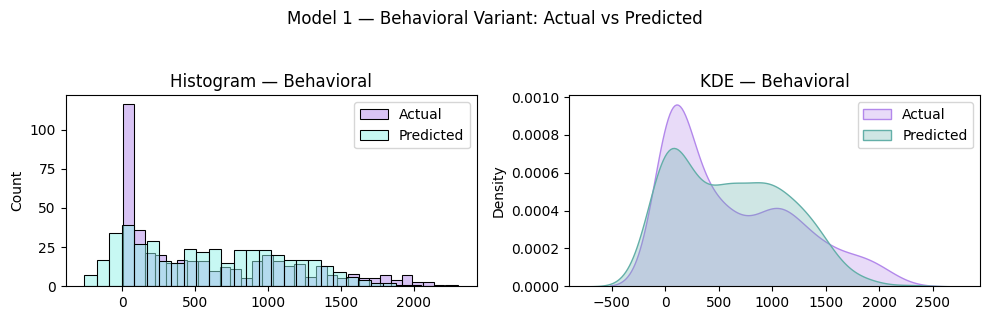

In [147]:
# ============================================================
# Model 1 — Behavioral Variant
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Histogram
sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)
sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9FF",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("Histogram — Behavioral")
axes[0].legend()

# KDE
sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)
sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8FF",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)
axes[1].set_title("KDE — Behavioral")
axes[1].legend()

plt.suptitle("Model 1 — Behavioral Variant: Actual vs Predicted", y=1.05)
plt.tight_layout()
plt.show()


#### 🔹 Variant B — Profile-only feature set

In [148]:
# ============================================================
# Model 1 — Linear Regression
# Variant B: Customer profile only (Refactored)
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

# ------------------------------------------------------------
# Variant B Feature Groups (Profile-only)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Variant B Preprocessor
# ------------------------------------------------------------

preprocessor_m1b = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_lr_m1b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m1b),
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr_m1b,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr_m1b.fit(X_train, y_train)

y_train_pred = pipe_lr_m1b.predict(X_train)
y_test_pred  = pipe_lr_m1b.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust)
# ------------------------------------------------------------

X_train_transformed = preprocessor_m1b.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_profile_model(
    name="Model 1 — Linear Regression(Baseline)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_test=mse_test,
    mse_train=mse_train,
    feature_count=feature_count,
    notes="Customer profile features only (income, age, household, education)"
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 1 — Linear Regression(Baseline)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 1 — Linear Regression(Baseline)
R² test : 0.686
R² train: 0.707
R² CV   : 0.701


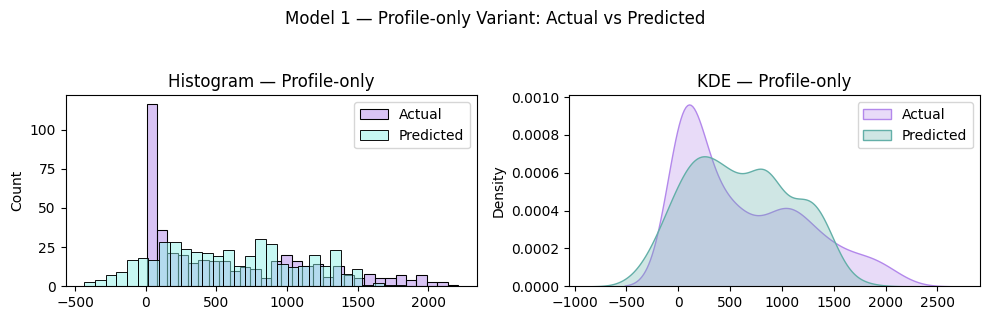

In [149]:
# ============================================================
# Model 1 — Profile-only Variant
# Actual vs Predicted (Test Set)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Histogram
sns.histplot(
    y_test,
    label="Actual",
    color="#B388EB",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)
sns.histplot(
    y_test_pred,
    label="Predicted",
    color="#91F3E9FF",
    bins=30,
    alpha=0.5,
    ax=axes[0]
)
axes[0].set_title("Histogram — Profile-only")
axes[0].legend()

# KDE
sns.kdeplot(
    y_test,
    label="Actual",
    color="#B388EB",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)
sns.kdeplot(
    y_test_pred,
    label="Predicted",
    color="#63AFA8FF",
    fill=True,
    alpha=0.3,
    ax=axes[1]
)
axes[1].set_title("KDE — Profile-only")
axes[1].legend()

plt.suptitle("Model 1 — Profile-only Variant: Actual vs Predicted", y=1.05)
plt.tight_layout()
plt.show()


### Model 2 — Linear Regression (EDA-based Features)

This model uses a reduced set of features selected based on EDA insights.
It is evaluated under two scenarios:
- Behavioral feature set (EDA-based upper-bound benchmark)
- Customer profile feature set (EDA-based realistic scenario)

#### 🔹 Variant A — Profile + Behavioral feature set

In [150]:
# ============================================================
# Model 2 — Linear Regression
# Behavioral variant (EDA-based features)
# ============================================================

# ------------------------------------------------------------
# Feature groups (EDA-based, CLEAN)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_scaled_cols = [
    "Tenure_Days"
]

numeric_count_cols = [
    "Kidhome",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebPurchases",
    "NumWebVisitsMonth"
]

categorical_cols = [
    "Education",
    "Marital_Status",
    "AcceptedCmp1",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

# ------------------------------------------------------------
# Preprocessor (EDA-based)
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_lr = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("lr", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr.fit(X_train, y_train)

y_train_pred = pipe_lr.predict(X_train)
y_test_pred  = pipe_lr.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust)
# ------------------------------------------------------------

X_train_transformed = preprocessor.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging (NAME UNCHANGED)
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 2 — Linear Regression (EDA-based features)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="EDA-based behavioral feature selection"
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 2 — Linear Regression variant (EDA-based features)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 2 — Linear Regression variant (EDA-based features)
R² test : 0.821
R² train: 0.818
R² CV   : 0.809


#### 🔹 Variant B — Profile-only feature set

In [151]:
# ============================================================
# Model 2 — Linear Regression
# Profile-only variant (EDA-based features)
# ============================================================

# ------------------------------------------------------------
# Feature groups (Profile-only, EDA-based)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_count_cols = [
    "Kidhome",
    #"Teenhome" #intentionally excluded (EDA decision)
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_lr = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("lr", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr.fit(X_train, y_train)

y_train_pred = pipe_lr.predict(X_train)
y_test_pred  = pipe_lr.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust)
# ------------------------------------------------------------

X_train_transformed = preprocessor.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging (NAME UNCHANGED)
# ------------------------------------------------------------

log_profile_model(
    name="Model 2 — Linear Regression (EDA-based features)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="EDA-based profile feature selection"
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 2 — Linear Regression (EDA-based features)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 2 — Linear Regression (EDA-based features)
R² test : 0.660
R² train: 0.685
R² CV   : 0.679


### Model 3 — Ridge Regression (Regularized Linear Model)

This model extends linear regression by applying L2 regularization (Ridge)
to mitigate multicollinearity and improve coefficient stability.

The model is evaluated under two feature scenarios:
- Behavioral feature set (upper-bound benchmark)
- Customer profile feature set (realistic predictive scenario)



#### 🔹 Variant A — Profile + Behavioral feature set


In [152]:
# ============================================================
# Model 3 — Ridge Regression
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Feature groups (UNCHANGED — exactly as you defined)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_scaled_cols = [
    "Tenure_Days",
    "Recency"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

binary_cols = [
    "Complain"
]

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor (same groups, just organized)
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("binary", "passthrough", binary_cols),
        ("campaign", "passthrough", campaign_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Ridge model (inner CV for alpha)
# ------------------------------------------------------------

alphas = np.logspace(-3, 3, 50)
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

ridge = RidgeCV(
    alphas=alphas,
    cv=cv_inner,
    scoring="r2"
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipe_ridge = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("ridge", ridge)
])

# ------------------------------------------------------------
# Outer CV (evaluation)
# ------------------------------------------------------------

cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_ridge,
    X_train,
    y_train,
    cv=cv_outer,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_ridge.fit(X_train, y_train)

y_train_pred = pipe_ridge.predict(X_train)
y_test_pred  = pipe_ridge.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust, pipeline-consistent)
# ------------------------------------------------------------

X_train_transformed = preprocessor.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging (NAME UNCHANGED)
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 3 — Ridge Regression",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Behavioral feature set with Ridge regularization (pipeline-based)"
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 3 — Ridge Regression")
print(f"Best α  : {pipe_ridge.named_steps['ridge'].alpha_:.5f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 3 — Ridge Regression
Best α  : 25.59548
R² test : 0.831
R² train: 0.828
R² CV   : 0.820


#### 🔹 Variant B — Profile-only feature set

In [153]:
# ============================================================
# Model 3 — Ridge Regression
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Feature groups (PROFILE-ONLY, same STRUCTURE as Variant A)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor (group-based, Variant A–like)
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Ridge model (inner CV for alpha)
# ------------------------------------------------------------

alphas = np.logspace(-3, 3, 50)
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

ridge = RidgeCV(
    alphas=alphas,
    cv=cv_inner,
    scoring="r2"
)

# ------------------------------------------------------------
# Pipeline (SAME STYLE as Variant A)
# ------------------------------------------------------------

pipe_ridge = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("ridge", ridge)
])

# ------------------------------------------------------------
# Outer CV
# ------------------------------------------------------------

cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_ridge,
    X_train,
    y_train,
    cv=cv_outer,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_ridge.fit(X_train, y_train)

y_train_pred = pipe_ridge.predict(X_train)
y_test_pred  = pipe_ridge.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (pipeline-consistent)
# ------------------------------------------------------------

X_train_transformed = preprocessor.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]

# ------------------------------------------------------------
# Logging (NAME UNCHANGED)
# ------------------------------------------------------------

log_profile_model(
    name="Model 3 — Ridge Regression",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Profile-only feature set with group-based preprocessing and Ridge regularization"
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 3 — Ridge Regression")
print(f"Best α  : {pipe_ridge.named_steps['ridge'].alpha_:.5f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 3 — Ridge Regression
Best α  : 19.30698
R² test : 0.687
R² train: 0.706
R² CV   : 0.702


### Model 4 — Lasso Regression (Automatic Feature Selection)

This model applies L1 regularization (Lasso) to automatically select a sparse
set of informative features by shrinking less relevant coefficients to zero.

The model is evaluated under two feature scenarios:
- Behavioral feature set (upper-bound benchmark)
- Customer profile feature set (realistic predictive scenario)


#### 🔹 Variant A — Profile + Behavioral feature set

In [154]:
# ============================================================
# Model 4 — LassoCV
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Feature groups (UNCHANGED CONCEPTUALLY, just organized)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_scaled_cols = [
    "Tenure_Days",
    "Recency"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

binary_cols = [
    "Complain"
]

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor (group-based, same as previous models)
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("binary", "passthrough", binary_cols),
        ("campaign", "passthrough", campaign_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

# ------------------------------------------------------------
# Lasso model (inner CV for alpha)
# ------------------------------------------------------------

alphas = np.logspace(-4, 1, 50)
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

lasso = LassoCV(
    alphas=alphas,
    cv=cv_inner,
    max_iter=50000,
    random_state=42
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipe_lasso = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("lasso", lasso)
])

# ------------------------------------------------------------
# Outer CV
# ------------------------------------------------------------

cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lasso,
    X_train,
    y_train,
    cv=cv_outer,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lasso.fit(X_train, y_train)

y_train_pred = pipe_lasso.predict(X_train)
y_test_pred  = pipe_lasso.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO coefficients)
# ------------------------------------------------------------

feature_names = pipe_lasso.named_steps["pre"].get_feature_names_out()
coefs = pipe_lasso.named_steps["lasso"].coef_

selected = [
    (name, coef)
    for name, coef in zip(feature_names, coefs)
    if coef != 0
]

selected_sorted = sorted(
    selected, key=lambda x: abs(x[1]), reverse=True
)

n_selected = len(selected_sorted)

# ------------------------------------------------------------
# Logging (NAME UNCHANGED)
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 4 — LassoCV",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=n_selected,
    notes="Behavioral feature set with L1 regularization (group-based pipeline)"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 4 — LassoCV")
print(f"Best α  : {pipe_lasso.named_steps['lasso'].alpha_:.6f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"\nSelected features: {n_selected} / {len(feature_names)}")

for name, coef in selected_sorted:
    print(f"  {name:45s}  coef = {coef:+.4f}")


Model 4 — LassoCV
Best α  : 1.526418
R² test : 0.832
R² train: 0.828
R² CV   : 0.820

Selected features: 19 / 29
  campaign__AcceptedCmp5                         coef = +273.8161
  num_capped__Income                             coef = +211.2194
  num_count__NumCatalogPurchases                 coef = +175.1163
  num_count__NumStorePurchases                   coef = +100.3836
  campaign__AcceptedCmp1                         coef = +73.9290
  num_count__Teenhome                            coef = -70.2358
  campaign__AcceptedCmp4                         coef = +67.0299
  num_count__NumWebPurchases                     coef = +65.8118
  num_scaled__Tenure_Days                        coef = +50.3029
  num_count__Kidhome                             coef = -47.5253
  campaign__Response                             coef = +33.7256
  cat__Education_2n Cycle                        coef = -26.9896
  num_count__NumWebVisitsMonth                   coef = +14.7712
  num_scaled__Recency                 

#### 🔹 Variant B — Profile-only feature set

In [155]:
# ============================================================
# Model 4 — LassoCV
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Feature groups (PROFILE-ONLY, group-based)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor (same STRUCTURE as other models)
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

# ------------------------------------------------------------
# LassoCV (inner CV for alpha)
# ------------------------------------------------------------

alphas = np.logspace(-4, 1, 50)
cv_inner = KFold(n_splits=5, shuffle=True, random_state=42)

lasso = LassoCV(
    alphas=alphas,
    cv=cv_inner,
    max_iter=50000,
    random_state=42
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipe_lasso = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("lasso", lasso)
])

# ------------------------------------------------------------
# Outer CV
# ------------------------------------------------------------

cv_outer = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lasso,
    X_train,
    y_train,
    cv=cv_outer,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lasso.fit(X_train, y_train)

y_train_pred = pipe_lasso.predict(X_train)
y_test_pred  = pipe_lasso.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO, with REAL names)
# ------------------------------------------------------------

feature_names = pipe_lasso.named_steps["pre"].get_feature_names_out()
coefs = pipe_lasso.named_steps["lasso"].coef_

selected = [
    (name, coef)
    for name, coef in zip(feature_names, coefs)
    if coef != 0
]

selected_sorted = sorted(
    selected,
    key=lambda x: abs(x[1]),
    reverse=True
)

n_selected = len(selected_sorted)

# ------------------------------------------------------------
# Logging (NAME UNCHANGED)
# ------------------------------------------------------------

log_profile_model(
    name="Model 4 — LassoCV",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=n_selected,
    notes="Profile-only feature set, group-based preprocessing, L1 regularization"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 4 — LassoCV")
print(f"Best α  : {pipe_lasso.named_steps['lasso'].alpha_:.6f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"\nSelected features: {n_selected} / {len(feature_names)}")

for name, coef in selected_sorted:
    print(f"  {name:45s}  coef = {coef:+.4f}")


Model 4 — LassoCV
Best α  : 3.088844
R² test : 0.688
R² train: 0.705
R² CV   : 0.703

Selected features: 5 / 15
  num_capped__Income                             coef = +427.8227
  num_count__Kidhome                             coef = -118.3085
  num_count__Teenhome                            coef = -96.6519
  cat__Education_2n Cycle                        coef = -17.6722
  num_capped__Age                                coef = -6.1988


### Model 5 — Lasso Regression (Fixed Alpha)

This model applies L1 regularization with a fixed regularization strength (α),
selected based on the results of LassoCV.  
Fixing α allows for a more stable and interpretable sparse solution.

The model is evaluated under two feature scenarios:
- Behavioral feature set (upper-bound benchmark)
- Customer profile feature set (realistic predictive scenario)


#### 🔹 Variant A — Profile + Behavioral feature set

In [156]:
# ============================================================
# Model 5 — Lasso Regression (Fixed Alpha)
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Feature groups (SAME as Model 4 Variant A)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_scaled_cols = [
    "Tenure_Days",
    "Recency"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

binary_cols = [
    "Complain"
]

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor (group-based)
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("binary", "passthrough", binary_cols),
        ("campaign", "passthrough", campaign_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

# ------------------------------------------------------------
# Fixed-alpha Lasso
# ------------------------------------------------------------

alpha_fixed = 13 # from LassoCV

lasso_fixed = Lasso(
    alpha=alpha_fixed,
    max_iter=50000,
    random_state=42
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipe_lasso_fixed = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("lasso", lasso_fixed)
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lasso_fixed,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lasso_fixed.fit(X_train, y_train)

y_train_pred = pipe_lasso_fixed.predict(X_train)
y_test_pred  = pipe_lasso_fixed.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO)
# ------------------------------------------------------------

feature_names = pipe_lasso_fixed.named_steps["pre"].get_feature_names_out()
coefs = pipe_lasso_fixed.named_steps["lasso"].coef_

selected = [(n, c) for n, c in zip(feature_names, coefs) if c != 0]
selected_sorted = sorted(selected, key=lambda x: abs(x[1]), reverse=True)
n_selected = len(selected_sorted)

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 5 — Lasso Regression (Fixed Alpha)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=n_selected,
    notes="Behavioral features, fixed alpha from LassoCV (α = 1.526)"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 5 — Lasso Regression (Fixed Alpha)")
print(f"Alpha fixed: {alpha_fixed:.6f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"\nSelected features: {n_selected}")

for name, coef in selected_sorted:
    print(f"  {name:45s}  coef = {coef:+.4f}")


Model 5 — Lasso Regression (Fixed Alpha)
Alpha fixed: 13.000000
R² test : 0.827
R² train: 0.816
R² CV   : 0.813

Selected features: 8
  num_capped__Income                             coef = +220.5518
  num_count__NumCatalogPurchases                 coef = +180.7578
  campaign__AcceptedCmp5                         coef = +156.6733
  num_count__NumStorePurchases                   coef = +92.3316
  num_count__NumWebPurchases                     coef = +67.7494
  num_count__Teenhome                            coef = -66.2470
  num_scaled__Tenure_Days                        coef = +45.9015
  num_count__Kidhome                             coef = -38.5573


##### 🔹 Coefficient Path — Variant A (Behavioral)

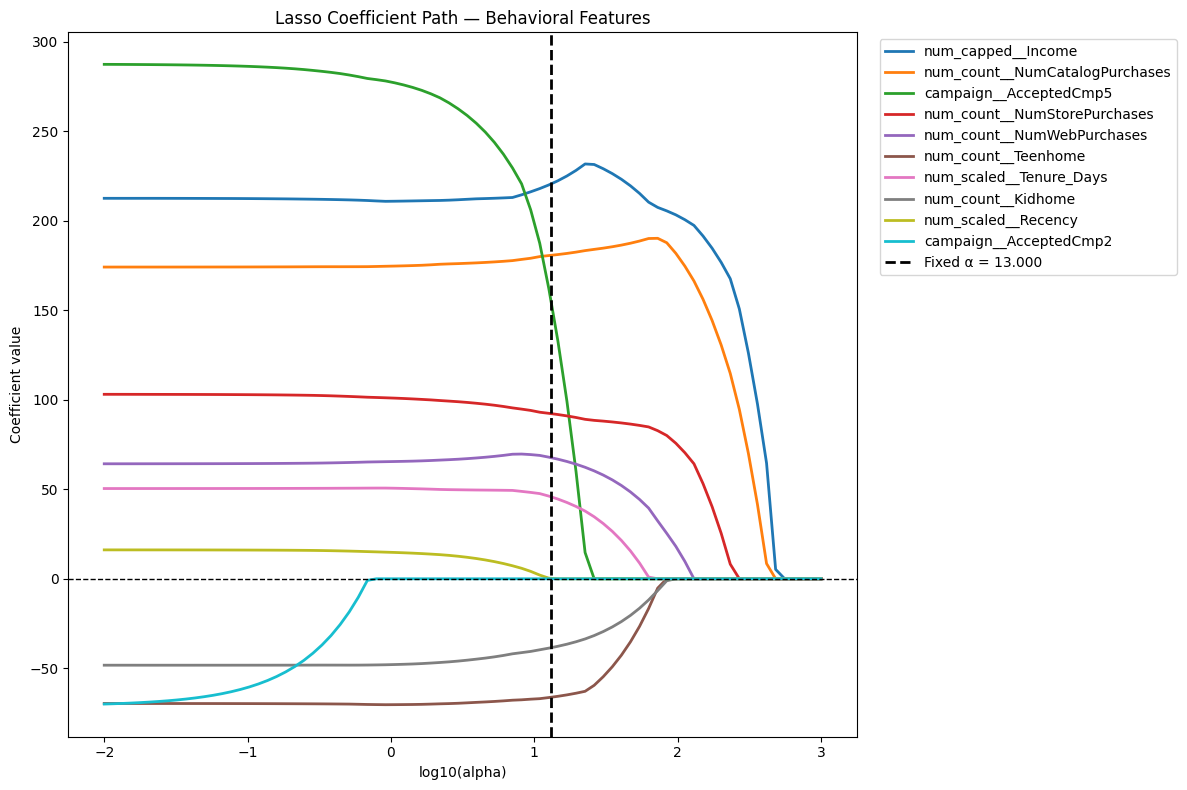

In [157]:
# ============================================================
# Lasso Coefficient Path — Variant A (Behavioral)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

# ------------------------------------------------------------
# Prepare design matrix (USING SAME PIPELINE AS MODEL 5)
# ------------------------------------------------------------

X_train_prepared = preprocessor.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_names = preprocessor.get_feature_names_out()

# ------------------------------------------------------------
# Alpha grid (MUST cover fixed alpha ≈ 1.53)
# ------------------------------------------------------------

alphas = np.logspace(-2, 3, 80)   # up to 10 → safe

coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=50000)
    lasso.fit(X_train_prepared, y_train)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

# ------------------------------------------------------------
# Fixed alpha (from Model 5)
# ------------------------------------------------------------

alpha_fixed = 13  # same as in Model 5

idx_fixed = np.argmin(np.abs(alphas - alpha_fixed))
coef_at_fixed = coefs[idx_fixed]

# ------------------------------------------------------------
# Select top 10 features by |coef| at fixed alpha
# ------------------------------------------------------------

top_idx_sorted = np.argsort(np.abs(coef_at_fixed))[-10:][::-1]

# ------------------------------------------------------------
# Plot coefficient paths
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

for i in top_idx_sorted:
    plt.plot(
        np.log10(alphas),
        coefs[:, i],
        linewidth=2,
        label=feature_names[i]
    )

plt.axvline(
    np.log10(alpha_fixed),
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Fixed α = {alpha_fixed:.3f}"
)

plt.axhline(y=0, color="black", linestyle="--", linewidth=1)

y_min = coefs[:, top_idx_sorted].min()
y_max = coefs[:, top_idx_sorted].max()
pad = 0.05 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)

plt.xlabel("log10(alpha)")
plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient Path — Behavioral Features")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


#### 🔹 Variant B — Profile-only feature set

In [158]:
# ============================================================
# Model 5 — Lasso Regression (Fixed Alpha)
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Feature groups (PROFILE-ONLY, consistent with other models)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income",
    "Age"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome"
]

categorical_cols = [
    "Education",
    "Marital_Status"
]

# ------------------------------------------------------------
# Preprocessor (group-based)
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

# ------------------------------------------------------------
# Fixed-alpha Lasso
# ------------------------------------------------------------

alpha_fixed = 10

lasso_fixed = Lasso(
    alpha=alpha_fixed,
    max_iter=50000,
    random_state=42
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

pipe_lasso_fixed = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("pre", preprocessor),
    ("lasso", lasso_fixed)
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lasso_fixed,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lasso_fixed.fit(X_train, y_train)

y_train_pred = pipe_lasso_fixed.predict(X_train)
y_test_pred  = pipe_lasso_fixed.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Selected features (NON-ZERO)
# ------------------------------------------------------------

feature_names = pipe_lasso_fixed.named_steps["pre"].get_feature_names_out()
coefs = pipe_lasso_fixed.named_steps["lasso"].coef_

selected = [(n, c) for n, c in zip(feature_names, coefs) if c != 0]
selected_sorted = sorted(selected, key=lambda x: abs(x[1]), reverse=True)
n_selected = len(selected_sorted)

# ------------------------------------------------------------
# Logging (NAME UNCHANGED)
# ------------------------------------------------------------

log_profile_model(
    name="Model 5 — Lasso Regression (Fixed Alpha)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=n_selected,
    notes="Profile-only features, fixed alpha = 3.5"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("Model 5 — Lasso Regression (Fixed Alpha)")
print(f"Alpha fixed: {alpha_fixed}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"\nSelected features: {n_selected}")

for name, coef in selected_sorted:
    print(f"  {name:45s}  coef = {coef:+.4f}")


Model 5 — Lasso Regression (Fixed Alpha)
Alpha fixed: 10
R² test : 0.687
R² train: 0.704
R² CV   : 0.703

Selected features: 3
  num_capped__Income                             coef = +422.8533
  num_count__Kidhome                             coef = -112.3349
  num_count__Teenhome                            coef = -91.4114


##### 🔹 Coefficient Path — Variant B (Profile-only)

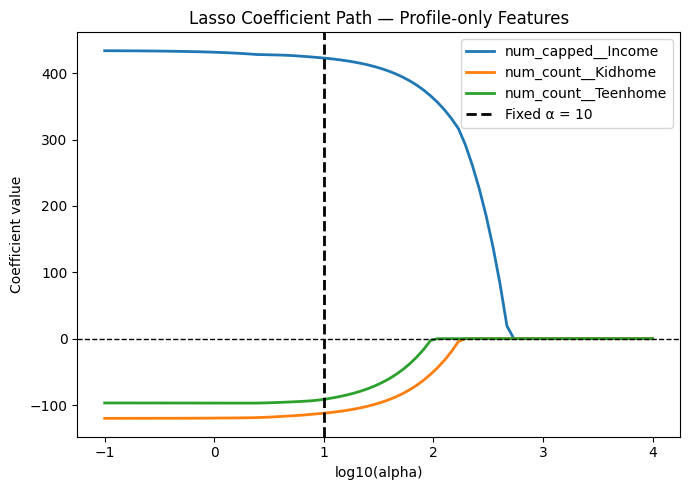

In [159]:
# ============================================================
# Lasso Coefficient Path — Variant B (Profile-only)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

# ------------------------------------------------------------
# Prepare design matrix (USING SAME PIPELINE AS MODEL 5)
# ------------------------------------------------------------

X_train_prepared = preprocessor.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_names = preprocessor.get_feature_names_out()

# ------------------------------------------------------------
# Alpha grid (MUST include alpha = 3.5)
# ------------------------------------------------------------

alphas = np.logspace(-1, 4, 80)   # up to 10 → safe

coefs = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=50000)
    lasso.fit(X_train_prepared, y_train)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

# ------------------------------------------------------------
# Fixed alpha (from Model 5 — Variant B)
# ------------------------------------------------------------

alpha_fixed = 10
idx_fixed = np.argmin(np.abs(alphas - alpha_fixed))
coef_at_fixed = coefs[idx_fixed]

# ------------------------------------------------------------
# Select non-zero features at fixed alpha
# (usually very few for profile-only)
# ------------------------------------------------------------

top_idx_sorted = np.argsort(np.abs(coef_at_fixed))[::-1]
active_idx = [i for i in top_idx_sorted if coef_at_fixed[i] != 0]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

for i in active_idx:
    plt.plot(
        np.log10(alphas),
        coefs[:, i],
        linewidth=2,
        label=feature_names[i]
    )

plt.axvline(
    np.log10(alpha_fixed),
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Fixed α = {alpha_fixed}"
)

plt.axhline(y=0, color="black", linestyle="--", linewidth=1)

plt.xlabel("log10(alpha)")
plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient Path — Profile-only Features")
plt.legend()
plt.tight_layout()
plt.show()


### Model 6 — Linear Regression (Lasso-selected Features)

This model retrains a linear regression using only the features selected
by Lasso with a fixed regularization strength (α = 0.03).

By removing regularization in the final step, this model evaluates whether
Lasso-selected features can achieve strong performance while improving
interpretability and coefficient stability.

The model is evaluated under two scenarios:
- Behavioral feature set (upper-bound benchmark)
- Customer profile feature set (realistic predictive scenario)


#### 🔹 Variant A — Profile + Behavioral feature set

In [160]:
# ============================================================
# Model 6 — Linear Regression
# Variant A: Top-8 Lasso-selected features (Clean, Group-based)
# ============================================================

# ------------------------------------------------------------
# Variant A Feature Groups
# (ONLY the 8 features selected by Lasso, alpha = 13)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income"          
]

numeric_scaled_cols = [
    "Tenure_Days"
]

numeric_count_cols = [
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebPurchases",
    "Teenhome",
    "Kidhome"
]

binary_cols = [
    "AcceptedCmp5"
]

# ------------------------------------------------------------
# Variant A Preprocessor
# ------------------------------------------------------------

preprocessor_m6 = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_scaled", numeric_scaled_pipeline, numeric_scaled_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
        ("binary", "passthrough", binary_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_lr_m6 = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m6),
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr_m6,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr_m6.fit(X_train, y_train)

y_train_pred = pipe_lr_m6.predict(X_train)
y_test_pred  = pipe_lr_m6.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Feature count (robust)
# ------------------------------------------------------------

X_train_transformed = preprocessor_m6.fit_transform(
    DeterministicFeatureBuilder().fit_transform(X_train)
)

feature_count = X_train_transformed.shape[1]   # should be 8

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_behavioral_model(
    name="Model 6 — Linear Regression (Top-8 Lasso-selected)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_test=mse_test,
    mse_train=mse_train,
    feature_count=feature_count,
    notes=(
        "Linear regression on 8 features selected via Lasso (alpha = 13). "
        "Clean group-based preprocessing, one representation per concept."
    )
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 6 — Linear Regression (Top-8 Lasso-selected)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 6 — Linear Regression (Top-8 Lasso-selected)
R² test : 0.829
R² train: 0.823
R² CV   : 0.820


#### 🔹 Variant B — Profile-only feature set

In [161]:
# ============================================================
# Model 6 — Linear Regression (Lasso-selected features)
# Variant B: Profile-only feature set (Clean)
# ============================================================

# ------------------------------------------------------------
# Variant B Feature Groups (ONLY selected profile features)
# ------------------------------------------------------------

numeric_capped_cols = [
    "Income"
]

numeric_count_cols = [
    "Kidhome",
    "Teenhome"
]

# ------------------------------------------------------------
# Variant B Preprocessor
# ------------------------------------------------------------

preprocessor_m6b = ColumnTransformer(
    transformers=[
        ("num_capped", numeric_capped_pipeline, numeric_capped_cols),
        ("num_count", numeric_count_pipeline, numeric_count_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ------------------------------------------------------------
# Pipeline: Feature Builder → Preprocessor → Linear Regression
# ------------------------------------------------------------

pipe_lr_m6b = Pipeline(steps=[
    ("feature_builder", DeterministicFeatureBuilder()),
    ("preprocessor", preprocessor_m6b),
    ("regressor", LinearRegression())
])

# ------------------------------------------------------------
# Cross-validation
# ------------------------------------------------------------

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_cv = cross_val_score(
    pipe_lr_m6b,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & Predict
# ------------------------------------------------------------

pipe_lr_m6b.fit(X_train, y_train)

y_train_pred = pipe_lr_m6b.predict(X_train)
y_test_pred  = pipe_lr_m6b.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test, y_test_pred)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# ------------------------------------------------------------
# Coefficients (interpretable)
# ------------------------------------------------------------

coefs = pipe_lr_m6b.named_steps["regressor"].coef_

coef_table = sorted(
    zip(numeric_capped_cols + numeric_count_cols, coefs),
    key=lambda x: abs(x[1]),
    reverse=True
)

# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

log_profile_model(
    name="Model 6 — Linear Regression (Lasso-selected)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=len(coef_table),
    notes=(
        "Linear regression on profile-only features selected via Lasso. "
        "Includes Income and household size indicators only."
    )
)

# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Model 6 — Linear Regression (Lasso-selected, Profile-only)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print("\nSelected coefficients (sorted by |coef|):")
for name, c in coef_table:
    print(f"{name:20s}  coef = {c:+.4f}")


Model 6 — Linear Regression (Lasso-selected, Profile-only)
R² test : 0.688
R² train: 0.705
R² CV   : 0.703

Selected coefficients (sorted by |coef|):
Income                coef = +429.6069
Kidhome               coef = -119.3048
Teenhome              coef = -101.9506


## 4. Polynomial Regression Models

Linear models assume additive and linear relationships between features and the target.
In this section, polynomial regression models are introduced to explicitly capture
second-order interactions and non-linear effects between predictors.

Polynomial features increase model flexibility by allowing interactions such as:
- Income × Tenure
- Age²
- Income × Age

However, this increased flexibility also raises the risk of overfitting.
Therefore, polynomial models are evaluated both in unregularized and regularized forms
(Ridge and Lasso) to control model complexity.

All polynomial models use degree = 2 and follow the same leakage-safe preprocessing
and evaluation framework as previous models.


### Model 7 — Polynomial Linear Regression (degree = 2)

#### 🔹 Variant A — Profile + Behavioral feature set

In [206]:
# ============================================================
# Model 7 — Polynomial Linear Regression (degree = 2)
# Variant A: Behavioral feature set
# ============================================================

num_cols = [
    "Income_capped",
    "Age_capped",
    "Tenure_Days",
    "Recency",
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

cat_cols = [
    "Education",
    "Marital_Status",
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

X_train_m7 = X_train[num_cols + cat_cols]
X_test_m7  = X_test[num_cols + cat_cols]

y_train_m7 = y_train_log
y_test_m7  = y_test_log

# ------------------------------------------------------------
# Preprocessing: Polynomial only on numeric features
# ------------------------------------------------------------
num_poly = Pipeline(
    [
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", num_poly, num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

pipe_poly = Pipeline(
    [
        ("pre", preprocessor),
        ("linreg", LinearRegression())
    ]
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = cross_val_score(
    pipe_poly, X_train_m7, y_train_m7, cv=cv, scoring="r2"
).mean()

pipe_poly.fit(X_train_m7, y_train_m7)

y_train_pred = pipe_poly.predict(X_train_m7)
y_test_pred  = pipe_poly.predict(X_test_m7)

r2_train = r2_score(y_train_m7, y_train_pred)
r2_test  = r2_score(y_test_m7, y_test_pred)
mse_train = mean_squared_error(y_train_m7, y_train_pred)
mse_test  = mean_squared_error(y_test_m7, y_test_pred)

pre = pipe_poly.named_steps["pre"]
n_num_after = pre.named_transformers_["num"].named_steps["poly"].n_output_features_
n_cat_after = len(pre.named_transformers_["cat"].get_feature_names_out(cat_cols))
feature_count = n_num_after + n_cat_after

log_behavioral_model(
    name="Model 7 — Polynomial Linear Regression",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Polynomial degree=2 on behavioral features"
)

print("Model 7 — Polynomial Linear Regression")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print("\nFeature counts:")
print(f"  Numeric before:            {len(num_cols)}")
print(f"  Categorical before:        {len(cat_cols)}")
print(f"  Numeric after poly(deg=2): {n_num_after}")
print(f"  Categorical after OHE:     {n_cat_after}")
print(f"  TOTAL after preprocessing: {feature_count}")


Model 7 — Polynomial Linear Regression
R² test : 0.900
R² train: 0.961
R² CV   : 0.948

Feature counts:
  Numeric before:            11
  Categorical before:        9
  Numeric after poly(deg=2): 77
  Categorical after OHE:     16
  TOTAL after preprocessing: 93


#### Diagnostic plots — Model 7 (Variant A)

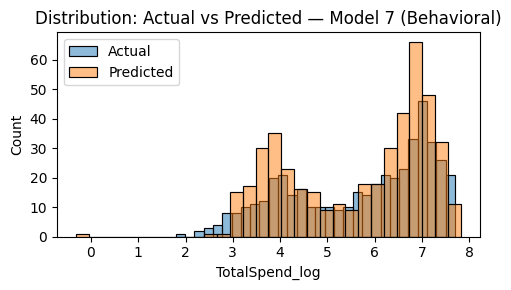

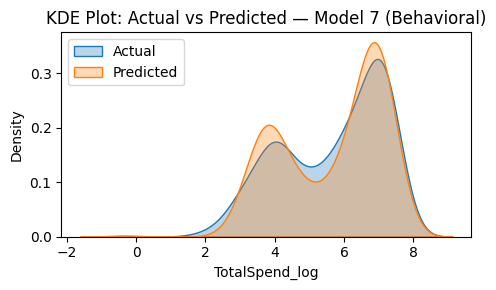

In [207]:
# ==========================================
# Diagnostic plots — Model 7 (Variant A)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Histogram: Actual vs Predicted
plt.figure(figsize=(5, 3))
sns.histplot(y_test_m7, label="Actual", bins=30, alpha=0.5)
sns.histplot(y_test_pred, label="Predicted", bins=30, alpha=0.5)
plt.title("Distribution: Actual vs Predicted — Model 7 (Behavioral)")
plt.xlabel("TotalSpend_log")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# KDE plot: Actual vs Predicted
plt.figure(figsize=(5, 3))
sns.kdeplot(y_test_m7, label="Actual", fill=True, alpha=0.3)
sns.kdeplot(y_test_pred, label="Predicted", fill=True, alpha=0.3)
plt.title("KDE Plot: Actual vs Predicted — Model 7 (Behavioral)")
plt.xlabel("TotalSpend_log")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


#### 🔹 Variant B — Profile-only feature set

In [208]:
# ============================================================
# Model 7 — Polynomial Linear Regression (degree = 2)
# Variant B: Profile-only feature set
# ============================================================

num_cols = [
    "Income_capped",
    "Age_capped",
    "Kidhome",
    "Teenhome",
]

cat_cols = [
    "Education",
    "Marital_Status",
]

X_train_m7 = X_train[num_cols + cat_cols]
X_test_m7  = X_test[num_cols + cat_cols]

y_train_m7 = y_train_log
y_test_m7  = y_test_log

# ------------------------------------------------------------
# Preprocessing
#   - Polynomial only on numeric
#   - OHE on categorical
# ------------------------------------------------------------
num_poly = Pipeline(
    [
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", num_poly, num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

pipe_poly = Pipeline(
    [
        ("pre", preprocessor),
        ("linreg", LinearRegression())
    ]
)

# ------------------------------------------------------------
# CV (train only)
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = cross_val_score(
    pipe_poly, X_train_m7, y_train_m7, cv=cv, scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & evaluate
# ------------------------------------------------------------
pipe_poly.fit(X_train_m7, y_train_m7)

y_train_pred = pipe_poly.predict(X_train_m7)
y_test_pred  = pipe_poly.predict(X_test_m7)

r2_train = r2_score(y_train_m7, y_train_pred)
r2_test  = r2_score(y_test_m7, y_test_pred)
mse_train = mean_squared_error(y_train_m7, y_train_pred)
mse_test  = mean_squared_error(y_test_m7, y_test_pred)

# ------------------------------------------------------------
# Feature count diagnostics
# ------------------------------------------------------------
pre = pipe_poly.named_steps["pre"]

# numeric after polynomial expansion
n_num_after = (
    pre
    .named_transformers_["num"]
    .named_steps["poly"]
    .n_output_features_
)

# categorical after OHE
n_cat_after = len(
    pre
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)

feature_count = n_num_after + n_cat_after

# ------------------------------------------------------------
# Log results
# ------------------------------------------------------------
log_profile_model(
    name="Model 7 — Polynomial Linear Regression",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Polynomial degree=2 on profile-only features (numeric + categorical)"
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("Model 7 — Polynomial Linear Regression")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print("\nFeature counts:")
print(f"  Numeric before:            {len(num_cols)}")
print(f"  Categorical before:        {len(cat_cols)}")
print(f"  Numeric after poly(deg=2): {n_num_after}")
print(f"  Categorical after OHE:     {n_cat_after}")
print(f"  TOTAL after preprocessing: {feature_count}")


Model 7 — Polynomial Linear Regression
R² test : 0.717
R² train: 0.728
R² CV   : 0.717

Feature counts:
  Numeric before:            4
  Categorical before:        2
  Numeric after poly(deg=2): 14
  Categorical after OHE:     9
  TOTAL after preprocessing: 23


#### Diagnostic plots — Model 7 (Variant B)

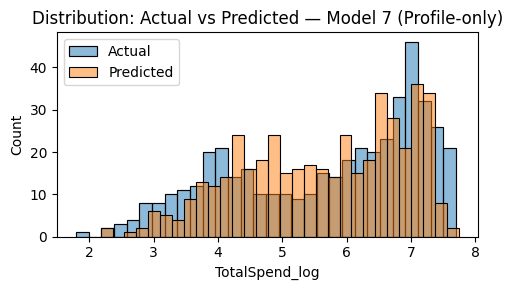

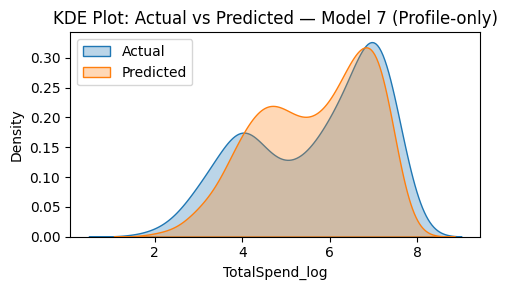

In [209]:
# ==========================================
# Diagnostic plots — Model 7 (Variant B)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Histogram: Actual vs Predicted
plt.figure(figsize=(5, 3))
sns.histplot(y_test_m7, label="Actual", bins=30, alpha=0.5)
sns.histplot(y_test_pred, label="Predicted", bins=30, alpha=0.5)
plt.title("Distribution: Actual vs Predicted — Model 7 (Profile-only)")
plt.xlabel("TotalSpend_log")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# KDE plot: Actual vs Predicted
plt.figure(figsize=(5, 3))
sns.kdeplot(y_test_m7, label="Actual", fill=True, alpha=0.3)
sns.kdeplot(y_test_pred, label="Predicted", fill=True, alpha=0.3)
plt.title("KDE Plot: Actual vs Predicted — Model 7 (Profile-only)")
plt.xlabel("TotalSpend_log")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


### Model 8 — Polynomial Ridge Regression (degree = 2)

#### 🔹 Variant A — Profile + Behavioral feature set

In [210]:
# ============================================================
# Model 8 — Polynomial Ridge Regression (degree = 2)
# Variant A: Behavioral feature set
# ============================================================

num_cols = [
    "Income_capped",
    "Age_capped",
    "Tenure_Days",
    "Recency",
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

cat_cols = [
    "Education",
    "Marital_Status",
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

X_train_m8 = X_train[num_cols + cat_cols]
X_test_m8  = X_test[num_cols + cat_cols]

y_train_m8 = y_train_log
y_test_m8  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
num_poly = Pipeline(
    [
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", num_poly, num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

# ------------------------------------------------------------
# RidgeCV
# ------------------------------------------------------------
alphas = np.logspace(-2, 2, 50)
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

ridge = RidgeCV(
    alphas=alphas,
    cv=cv5,
    scoring="r2"
)

pipe_ridge_poly = Pipeline(
    [
        ("pre", preprocessor),
        ("ridge", ridge)
    ]
)

# ------------------------------------------------------------
# CV (train only)
# ------------------------------------------------------------
r2_cv = cross_val_score(
    pipe_ridge_poly, X_train_m8, y_train_m8, cv=cv5, scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & evaluate
# ------------------------------------------------------------
pipe_ridge_poly.fit(X_train_m8, y_train_m8)

y_train_pred = pipe_ridge_poly.predict(X_train_m8)
y_test_pred  = pipe_ridge_poly.predict(X_test_m8)

r2_train = r2_score(y_train_m8, y_train_pred)
r2_test  = r2_score(y_test_m8, y_test_pred)
mse_train = mean_squared_error(y_train_m8, y_train_pred)
mse_test  = mean_squared_error(y_test_m8, y_test_pred)

# ------------------------------------------------------------
# Feature count diagnostics
# ------------------------------------------------------------
pre = pipe_ridge_poly.named_steps["pre"]

n_num_after = (
    pre
    .named_transformers_["num"]
    .named_steps["poly"]
    .n_output_features_
)

n_cat_after = len(
    pre
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)

feature_count = n_num_after + n_cat_after

# ------------------------------------------------------------
# Log
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 8 — Polynomial Ridge Regression",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Polynomial deg=2 + RidgeCV on behavioral features"
)

print("Model 8 — Polynomial Ridge Regression")
print(f"Best α: {pipe_ridge_poly.named_steps['ridge'].alpha_:.4f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print("\nFeature counts:")
print(f"  Numeric before:            {len(num_cols)}")
print(f"  Categorical before:        {len(cat_cols)}")
print(f"  Numeric after poly(deg=2): {n_num_after}")
print(f"  Categorical after OHE:     {n_cat_after}")
print(f"  TOTAL after preprocessing: {feature_count}")  


Model 8 — Polynomial Ridge Regression
Best α: 1.0985
R² test : 0.907
R² train: 0.961
R² CV   : 0.948

Feature counts:
  Numeric before:            11
  Categorical before:        9
  Numeric after poly(deg=2): 77
  Categorical after OHE:     16
  TOTAL after preprocessing: 93


#### 🔹 Variant B — Profile-only feature set

In [211]:
# ============================================================
# Model 8 — Polynomial Ridge Regression (degree = 2)
# Variant B: Profile-only feature set
# ============================================================

num_cols = [
    "Income_capped",
    "Age_capped",
    "Kidhome",
    "Teenhome"
]

cat_cols = [
    "Education",
    "Marital_Status"
]

X_train_m8 = X_train[num_cols + cat_cols]
X_test_m8  = X_test[num_cols + cat_cols]

y_train_m8 = y_train_log
y_test_m8  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
num_poly = Pipeline(
    [
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", num_poly, num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

# ------------------------------------------------------------
# RidgeCV
# ------------------------------------------------------------
alphas = np.logspace(-2, 2, 50)
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

ridge = RidgeCV(
    alphas=alphas,
    cv=cv5,
    scoring="r2"
)

pipe_ridge_poly = Pipeline(
    [
        ("pre", preprocessor),
        ("ridge", ridge)
    ]
)

# ------------------------------------------------------------
# CV (train only)
# ------------------------------------------------------------
r2_cv = cross_val_score(
    pipe_ridge_poly, X_train_m8, y_train_m8, cv=cv5, scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & evaluate
# ------------------------------------------------------------
pipe_ridge_poly.fit(X_train_m8, y_train_m8)

y_train_pred = pipe_ridge_poly.predict(X_train_m8)
y_test_pred  = pipe_ridge_poly.predict(X_test_m8)

r2_train = r2_score(y_train_m8, y_train_pred)
r2_test  = r2_score(y_test_m8, y_test_pred)
mse_train = mean_squared_error(y_train_m8, y_train_pred)
mse_test  = mean_squared_error(y_test_m8, y_test_pred)

# ------------------------------------------------------------
# Feature count diagnostics
# ------------------------------------------------------------
pre = pipe_ridge_poly.named_steps["pre"]

n_num_after = (
    pre
    .named_transformers_["num"]
    .named_steps["poly"]
    .n_output_features_
)

n_cat_after = len(
    pre
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)

feature_count = n_num_after + n_cat_after

# ------------------------------------------------------------
# Log
# ------------------------------------------------------------
log_profile_model(
    name="Model 8 — Polynomial Ridge Regression",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Polynomial deg=2 + RidgeCV on profile-only features"
)

print("Model 8 — Polynomial Ridge Regression")
print(f"Best α: {pipe_ridge_poly.named_steps['ridge'].alpha_:.4f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
# ============================================================
print("\nFeature counts:")
print(f"  Numeric before:            {len(num_cols)}")
print(f"  Categorical before:        {len(cat_cols)}")
print(f"  Numeric after poly(deg=2): {n_num_after}")
print(f"  Categorical after OHE:     {n_cat_after}")
print(f"  TOTAL after preprocessing: {feature_count}")  

Model 8 — Polynomial Ridge Regression
Best α: 1.9307
R² test : 0.718
R² train: 0.728
R² CV   : 0.717

Feature counts:
  Numeric before:            4
  Categorical before:        2
  Numeric after poly(deg=2): 14
  Categorical after OHE:     9
  TOTAL after preprocessing: 23


### Model 9 — Polynomial LassoCV (degree = 2)

#### 🔹 Variant A — Profile + Behavioral feature set

In [212]:
# ============================================================
# Model 9 — Polynomial LassoCV (degree = 2)
# Variant A: Behavioral feature set
# ============================================================

num_cols = [
    "Income_capped",
    "Age_capped",
    "Tenure_Days",
    "Recency",
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

cat_cols = [
    "Education",
    "Marital_Status",
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

X_train_m9 = X_train[num_cols + cat_cols]
X_test_m9  = X_test[num_cols + cat_cols]

y_train_m9 = y_train_log
y_test_m9  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
num_poly = Pipeline(
    [
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", num_poly, num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

# ------------------------------------------------------------
# LassoCV
# ------------------------------------------------------------
alphas = np.logspace(-4, 1, 40)
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

lasso_cv = LassoCV(
    alphas=alphas,
    cv=cv5,
    max_iter=100000,
    random_state=42
)

pipe_lasso_poly = Pipeline(
    [
        ("pre", preprocessor),
        ("lasso", lasso_cv)
    ]
)

# ------------------------------------------------------------
# CV (train only)
# ------------------------------------------------------------
r2_cv = cross_val_score(
    pipe_lasso_poly, X_train_m9, y_train_m9, cv=cv5, scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & evaluate
# ------------------------------------------------------------
pipe_lasso_poly.fit(X_train_m9, y_train_m9)

y_train_pred = pipe_lasso_poly.predict(X_train_m9)
y_test_pred  = pipe_lasso_poly.predict(X_test_m9)

r2_train = r2_score(y_train_m9, y_train_pred)
r2_test  = r2_score(y_test_m9, y_test_pred)
mse_train = mean_squared_error(y_train_m9, y_train_pred)
mse_test  = mean_squared_error(y_test_m9, y_test_pred)

# ------------------------------------------------------------
# Selected features
# ------------------------------------------------------------
feature_names = pipe_lasso_poly.named_steps["pre"].get_feature_names_out()
coefs = pipe_lasso_poly.named_steps["lasso"].coef_

selected = [(n, c) for n, c in zip(feature_names, coefs) if abs(c) > 1e-8]
selected_sorted = sorted(selected, key=lambda x: abs(x[1]), reverse=True)
feature_count = len(selected)

# ------------------------------------------------------------
# Log
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 9 — Polynomial LassoCV",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Polynomial deg=2 + LassoCV on behavioral features"
)

print("Model 9 — Polynomial LassoCV")
print(f"Best α: {pipe_lasso_poly.named_steps['lasso'].alpha_:.6f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nTotal features after preprocessing: {len(feature_names)}")
selected_count = len([c for c in coefs if abs(c) > 1e-8])   
print(f"Selected (non-zero) features: {selected_count} / {len(feature_names)}")
print(f"\nSelected features: {feature_count }")
for name, coef in selected_sorted[:15]:
    print(f"{name:55s}  coef = {coef:+.4f}")



Model 9 — Polynomial LassoCV
Best α: 0.000242
R² test : 0.909
R² train: 0.961
R² CV   : 0.946

Total features after preprocessing: 93
Selected (non-zero) features: 90 / 93

Selected features: 90
num__NumWebPurchases                                     coef = +1.1406
num__Income_capped                                       coef = +1.0117
num__NumCatalogPurchases                                 coef = +0.8519
num__NumStorePurchases                                   coef = +0.5670
num__Income_capped^2                                     coef = -0.5258
num__NumCatalogPurchases^2                               coef = -0.4987
num__NumWebVisitsMonth^2                                 coef = +0.4119
num__NumCatalogPurchases NumStorePurchases               coef = -0.3812
num__NumWebPurchases^2                                   coef = -0.3696
num__Teenhome                                            coef = -0.3687
num__NumWebPurchases NumCatalogPurchases                 coef = -0.3527
num__Income_c

#### 🔹 Variant B — Profile-only feature set

In [213]:
# ============================================================
# Model 9 — Polynomial LassoCV (degree = 2)
# Variant B: Profile-only feature set
# ============================================================

num_cols = [
    "Income_capped",
    "Age_capped",
    "Kidhome",
    "Teenhome"
]

cat_cols = [
    "Education",
    "Marital_Status"
]

X_train_m9 = X_train[num_cols + cat_cols]
X_test_m9  = X_test[num_cols + cat_cols]

y_train_m9 = y_train_log
y_test_m9  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
num_poly = Pipeline(
    [
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", num_poly, num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

# ------------------------------------------------------------
# LassoCV
# ------------------------------------------------------------
alphas = np.logspace(-4, 1, 40)
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

lasso_cv = LassoCV(
    alphas=alphas,
    cv=cv5,
    max_iter=100000,
    random_state=42
)

pipe_lasso_poly = Pipeline(
    [
        ("pre", preprocessor),
        ("lasso", lasso_cv)
    ]
)

# ------------------------------------------------------------
# CV (train only)
# ------------------------------------------------------------
r2_cv = cross_val_score(
    pipe_lasso_poly, X_train_m9, y_train_m9, cv=cv5, scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit & evaluate
# ------------------------------------------------------------
pipe_lasso_poly.fit(X_train_m9, y_train_m9)

y_train_pred = pipe_lasso_poly.predict(X_train_m9)
y_test_pred  = pipe_lasso_poly.predict(X_test_m9)

r2_train = r2_score(y_train_m9, y_train_pred)
r2_test  = r2_score(y_test_m9, y_test_pred)
mse_train = mean_squared_error(y_train_m9, y_train_pred)
mse_test  = mean_squared_error(y_test_m9, y_test_pred)

# ------------------------------------------------------------
# Selected features
# ------------------------------------------------------------
feature_names = pipe_lasso_poly.named_steps["pre"].get_feature_names_out()
coefs = pipe_lasso_poly.named_steps["lasso"].coef_

selected = [(n, c) for n, c in zip(feature_names, coefs) if abs(c) > 1e-8]
selected_sorted = sorted(selected, key=lambda x: abs(x[1]), reverse=True)
feature_count = len(selected)

# ------------------------------------------------------------
# Log
# ------------------------------------------------------------
log_profile_model(
    name="Model 9 — Polynomial LassoCV",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Polynomial deg=2 + LassoCV on profile-only features"
)

print("Model 9 — Polynomial LassoCV")
print(f"Best α: {pipe_lasso_poly.named_steps['lasso'].alpha_:.6f}")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nTotal features after preprocessing: {len(feature_names)}")
selected_count = len([c for c in coefs if abs(c) > 1e-8])   
print(f"Selected (non-zero) features: {selected_count} / {len(feature_names)}")
print(f"\nSelected features: {feature_count}")
for name, coef in selected_sorted:
    print(f"{name:55s}  coef = {coef:+.4f}")


Model 9 — Polynomial LassoCV
Best α: 0.003455
R² test : 0.721
R² train: 0.726
R² CV   : 0.717

Total features after preprocessing: 23
Selected (non-zero) features: 14 / 23

Selected features: 14
num__Income_capped                                       coef = +2.0208
num__Income_capped^2                                     coef = -1.1350
num__Kidhome                                             coef = -0.3557
num__Teenhome                                            coef = -0.2834
num__Income_capped Teenhome                              coef = +0.1385
cat__Education_Basic                                     coef = +0.1313
num__Kidhome^2                                           coef = +0.0954
num__Teenhome^2                                          coef = +0.0641
num__Income_capped Kidhome                               coef = -0.0469
num__Kidhome Teenhome                                    coef = -0.0437
num__Age_capped Kidhome                                  coef = -0.0374
cat__Educatio

### Model 10 — Polynomial Lasso (degree = 2, fixed α)

#### 🔹 Variant A — Profile + Behavioral feature set

In [214]:
alpha_fixed = 0.016

num_cols = [
    "Income_capped",
    "Age_capped",
    "Tenure_Days",
    "Recency",
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

cat_cols = [
    "Education",
    "Marital_Status",
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

X_train_m10_A = X_train[num_cols + cat_cols]
X_test_m10_A  = X_test[num_cols + cat_cols]

y_train_m10 = y_train_log
y_test_m10  = y_test_log



num_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", num_poly, num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

lasso_fixed = Lasso(
    alpha=alpha_fixed,
    max_iter=100_000,
    random_state=42
)

pipe_lasso_poly_fixed_behavioral = Pipeline([
    ("pre", preprocessor),
    ("lasso", lasso_fixed)
])

pipe_lasso_poly_fixed_behavioral.fit(X_train_m10_A, y_train_m10)

y_train_pred = pipe_lasso_poly_fixed_behavioral.predict(X_train_m10_A)
y_test_pred  = pipe_lasso_poly_fixed_behavioral.predict(X_test_m10_A)

r2_train = r2_score(y_train_m10, y_train_pred)
r2_test  = r2_score(y_test_m10, y_test_pred)
mse_train = mean_squared_error(y_train_m10, y_train_pred)
mse_test  = mean_squared_error(y_test_m10, y_test_pred)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = cross_val_score(
    pipe_lasso_poly_fixed_behavioral, X_train_m10_A, y_train_m10, cv=cv, scoring="r2"
).mean()

feature_names = pipe_lasso_poly_fixed_behavioral.named_steps["pre"].get_feature_names_out()
coefs = pipe_lasso_poly_fixed_behavioral.named_steps["lasso"].coef_

selected = [(n, c) for n, c in zip(feature_names, coefs) if abs(c) > 1e-8]
selected_sorted = sorted(selected, key=lambda x: abs(x[1]), reverse=True)
selected_count = len(selected)

log_behavioral_model(
    name="Model 10 — Polynomial Lasso (fixed α)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=selected_count,
    notes=f"deg=2, fixed α={alpha_fixed}"
)

print("Model 10 — Polynomial Lasso (fixed α)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nSelected features: {selected_count} / {len(feature_names)}")
for name, coef in selected_sorted[:20]:
    print(f"{name:55s}  coef = {coef:+.4f}")


Model 10 — Polynomial Lasso (fixed α)
R² test : 0.938
R² train: 0.929
R² CV   : 0.925

Selected features: 21 / 93
num__NumCatalogPurchases                                 coef = +0.9738
num__NumWebPurchases                                     coef = +0.7368
num__NumStorePurchases                                   coef = +0.4838
num__NumCatalogPurchases^2                               coef = -0.3460
num__Income_capped                                       coef = +0.3287
num__NumWebPurchases^2                                   coef = -0.2422
num__Kidhome                                             coef = -0.2374
num__NumCatalogPurchases NumStorePurchases               coef = -0.2334
num__NumWebPurchases NumStorePurchases                   coef = -0.1941
num__NumWebPurchases NumCatalogPurchases                 coef = -0.1890
num__Tenure_Days                                         coef = +0.0788
num__Kidhome NumWebPurchases                             coef = +0.0679
num__Teenhome         

In [215]:
pipe_lasso_poly_fixed_behavioral

,steps,"[('pre', ...), ('lasso', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [216]:
pipe_lasso_poly_fixed_behavioral.named_steps.keys()

dict_keys(['pre', 'lasso'])

#### 🔹 Variant B — Profile-only feature set

In [217]:
alpha_fixed = 0.020

num_cols = [
    "Income_capped",
    "Age_capped",
    "Kidhome",
    "Teenhome"
]

cat_cols = [
    "Education",
    "Marital_Status"
]

X_train_m10_B = X_train[num_cols + cat_cols]
X_test_m10_B  = X_test[num_cols + cat_cols]

y_train_m10 = y_train_log
y_test_m10  = y_test_log

num_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", num_poly, num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

lasso_fixed = Lasso(
    alpha=alpha_fixed,
    max_iter=100_000,
    random_state=42
)

pipe_lasso_poly_fixed_profile = Pipeline([
    ("pre", preprocessor),
    ("lasso", lasso_fixed)
])

pipe_lasso_poly_fixed_profile.fit(X_train_m10_B, y_train_m10)

y_train_pred = pipe_lasso_poly_fixed_profile.predict(X_train_m10_B)
y_test_pred  = pipe_lasso_poly_fixed_profile.predict(X_test_m10_B)

r2_train = r2_score(y_train_m10, y_train_pred)
r2_test  = r2_score(y_test_m10, y_test_pred)
mse_train = mean_squared_error(y_train_m10, y_train_pred)
mse_test  = mean_squared_error(y_test_m10, y_test_pred)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = cross_val_score(
    pipe_lasso_poly_fixed_profile, X_train_m10_B, y_train_m10, cv=cv, scoring="r2"
).mean()

feature_names = pipe_lasso_poly_fixed_profile.named_steps["pre"].get_feature_names_out()
coefs = pipe_lasso_poly_fixed_profile.named_steps["lasso"].coef_

selected = [(n, c) for n, c in zip(feature_names, coefs) if abs(c) > 1e-8]
selected_sorted = sorted(selected, key=lambda x: abs(x[1]), reverse=True)
selected_count = len(selected)

log_profile_model(
    name="Model 10 — Polynomial Lasso (fixed α)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=selected_count,
    notes=f"deg=2, fixed α={alpha_fixed}"
)

print("Model 10 — Polynomial Lasso (fixed α)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nSelected features: {selected_count} / {len(feature_names)}")
for name, coef in selected_sorted:
    print(f"{name:55s}  coef = {coef:+.4f}")


Model 10 — Polynomial Lasso (fixed α)
R² test : 0.716
R² train: 0.713
R² CV   : 0.709

Selected features: 6 / 23
num__Income_capped                                       coef = +1.6606
num__Income_capped^2                                     coef = -0.7616
num__Kidhome                                             coef = -0.2606
num__Age_capped Kidhome                                  coef = -0.0774
num__Kidhome Teenhome                                    coef = -0.0698
num__Teenhome                                            coef = -0.0425


### Model 11 — Linear Regression (on Polynomial Lasso–selected features)

#### 🔹 Variant A — Profile + Behavioral feature set

In [218]:
# ------------------------------------------------------------
# 1) Polynomial feature space (from Model 10A)
# ------------------------------------------------------------
X_train_poly = pipe_lasso_poly_fixed_behavioral.named_steps["pre"].transform(X_train_m10_A)
X_test_poly  = pipe_lasso_poly_fixed_behavioral.named_steps["pre"].transform(X_test_m10_A)

feature_names_poly = (
    pipe_lasso_poly_fixed_behavioral
    .named_steps["pre"]
    .get_feature_names_out()
)

# ------------------------------------------------------------
# 2) Select polynomial features kept by Lasso
# ------------------------------------------------------------
coefs = pipe_lasso_poly_fixed_behavioral.named_steps["lasso"].coef_
selected_idx = [i for i, c in enumerate(coefs) if abs(c) > 1e-8]

X_train_sel = X_train_poly[:, selected_idx]
X_test_sel  = X_test_poly[:, selected_idx]

selected_feature_names = feature_names_poly[selected_idx]
feature_count = len(selected_idx)

# ------------------------------------------------------------
# 3) Linear Regression
# ------------------------------------------------------------
linreg = LinearRegression()

cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = cross_val_score(
    linreg, X_train_sel, y_train_log, cv=cv, scoring="r2"
).mean()

linreg.fit(X_train_sel, y_train_log)

# ------------------------------------------------------------
# 4) Metrics
# ------------------------------------------------------------
y_train_pred = linreg.predict(X_train_sel)
y_test_pred  = linreg.predict(X_test_sel)

r2_train = r2_score(y_train_log, y_train_pred)
r2_test  = r2_score(y_test_log, y_test_pred)
mse_train = mean_squared_error(y_train_log, y_train_pred)
mse_test  = mean_squared_error(y_test_log, y_test_pred)

# ------------------------------------------------------------
# 5) Coefficients
# ------------------------------------------------------------
coef_table = sorted(
    zip(selected_feature_names, linreg.coef_),
    key=lambda x: abs(x[1]),
    reverse=True
)

# ------------------------------------------------------------
# 6) Log + Print
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 11 — Linear Regression (Poly Lasso-selected)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Linear regression on polynomial features selected by Lasso (Model 10A)"
)

print("Model 11 — Linear Regression (Poly Lasso-selected)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nFinal feature count: {feature_count}")
print("\nTop coefficients:")
for name, coef in coef_table[:20]:
    print(f"{name:60s}  coef = {coef:+.4f}")


Model 11 — Linear Regression (Poly Lasso-selected)
R² test : 0.948
R² train: 0.946
R² CV   : 0.942

Final feature count: 21

Top coefficients:
num__NumCatalogPurchases                                      coef = +1.5728
num__NumWebPurchases                                          coef = +1.0508
num__NumStorePurchases                                        coef = +0.8278
num__NumCatalogPurchases NumStorePurchases                    coef = -0.6212
num__NumCatalogPurchases^2                                    coef = -0.5868
num__NumWebPurchases NumStorePurchases                        coef = -0.5128
num__NumWebPurchases^2                                        coef = -0.3788
num__Income_capped                                            coef = +0.3080
num__NumWebPurchases NumCatalogPurchases                      coef = -0.2888
num__Kidhome                                                  coef = -0.1500
num__NumWebVisitsMonth^2                                      coef = +0.1184
num__Teenh

#### 🔹 Variant B — Profile-only feature set

In [219]:
# ------------------------------------------------------------
# 1) Polynomial feature space (from Model 10B)
# ------------------------------------------------------------
X_train_poly = pipe_lasso_poly_fixed_profile.named_steps["pre"].transform(X_train_m10_B)
X_test_poly  = pipe_lasso_poly_fixed_profile.named_steps["pre"].transform(X_test_m10_B)

feature_names_poly = (
    pipe_lasso_poly_fixed_profile
    .named_steps["pre"]
    .get_feature_names_out()
)

# ------------------------------------------------------------
# 2) Select polynomial features kept by Lasso
# ------------------------------------------------------------
coefs = pipe_lasso_poly_fixed_profile.named_steps["lasso"].coef_
selected_idx = [i for i, c in enumerate(coefs) if abs(c) > 1e-8]

X_train_sel = X_train_poly[:, selected_idx]
X_test_sel  = X_test_poly[:, selected_idx]

selected_feature_names = feature_names_poly[selected_idx]
feature_count = len(selected_idx)

# ------------------------------------------------------------
# 3) Linear Regression
# ------------------------------------------------------------
linreg = LinearRegression()

cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = cross_val_score(
    linreg, X_train_sel, y_train_log, cv=cv, scoring="r2"
).mean()

linreg.fit(X_train_sel, y_train_log)

# ------------------------------------------------------------
# 4) Metrics
# ------------------------------------------------------------
y_train_pred = linreg.predict(X_train_sel)
y_test_pred  = linreg.predict(X_test_sel)

r2_train = r2_score(y_train_log, y_train_pred)
r2_test  = r2_score(y_test_log, y_test_pred)
mse_train = mean_squared_error(y_train_log, y_train_pred)
mse_test  = mean_squared_error(y_test_log, y_test_pred)

# ------------------------------------------------------------
# 5) Coefficients
# ------------------------------------------------------------
coef_table = sorted(
    zip(selected_feature_names, linreg.coef_),
    key=lambda x: abs(x[1]),
    reverse=True
)

# ------------------------------------------------------------
# 6) Log + Print
# ------------------------------------------------------------
log_profile_model(
    name="Model 11 — Linear Regression (Poly Lasso-selected)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Linear regression on polynomial features selected by Lasso (Model 10B)"
)

print("Model 11 — Linear Regression (Poly Lasso-selected)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")

print(f"\nFinal feature count: {feature_count}")
print("\nTop coefficients:")
for name, coef in coef_table[:20]:
    print(f"{name:60s}  coef = {coef:+.4f}")


Model 11 — Linear Regression (Poly Lasso-selected)
R² test : 0.715
R² train: 0.721
R² CV   : 0.718

Final feature count: 6

Top coefficients:
num__Income_capped                                            coef = +2.1001
num__Income_capped^2                                          coef = -1.1982
num__Kidhome                                                  coef = -0.2486
num__Teenhome                                                 coef = -0.0972
num__Age_capped Kidhome                                       coef = -0.0819
num__Kidhome Teenhome                                         coef = -0.0714


## 5. Decision Tree Models

Unlike linear and polynomial models, Decision Trees do not assume a fixed functional form.
They learn non-linear relationships and feature interactions
by recursively splitting the data into homogeneous regions.

This makes Decision Trees highly flexible and expressive,
but also prone to overfitting if not properly constrained.
Therefore, tree depth and splitting criteria must be carefully controlled.

In this section, Decision Tree regression models are evaluated
for both Behavioral and Profile-only feature sets,
using the same leakage-safe training and evaluation framework
as in previous sections.

### Model 12 — Regression Tree (DecisionTreeRegressor)

#### 🔹 Variant A — Profile + Behavioral feature set

In [220]:
# ============================================================
# Model 12 — Regression Tree
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Features (BEHAVIORAL)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Tenure_Days",
    "Recency",
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

cat_cols = [
    "Education",
    "Marital_Status",
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

X_train_m12 = X_train[num_cols + cat_cols]
X_test_m12  = X_test[num_cols + cat_cols]

y_train_m12 = y_train_log
y_test_m12  = y_test_log

# ------------------------------------------------------------
# Preprocessing (OHE only for categoricals)
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------
tree = DecisionTreeRegressor(random_state=42)

pipe_tree = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("tree", tree)
    ]
)

# ------------------------------------------------------------
# CV (train only)
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = cross_val_score(
    pipe_tree, X_train_m12, y_train_m12, cv=cv, scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_tree.fit(X_train_m12, y_train_m12)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_tree.predict(X_train_m12)
y_test_pred  = pipe_tree.predict(X_test_m12)

r2_train = r2_score(y_train_m12, y_train_pred)
r2_test  = r2_score(y_test_m12, y_test_pred)
mse_train = mean_squared_error(y_train_m12, y_train_pred)
mse_test  = mean_squared_error(y_test_m12, y_test_pred)

# ------------------------------------------------------------
# Feature count AFTER preprocessing
# ------------------------------------------------------------
pre_fitted = pipe_tree.named_steps["pre"]

n_cat_after = len(
    pre_fitted
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)

n_num_after = len(num_cols)
feature_count = n_num_after + n_cat_after

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------
tree_est = pipe_tree.named_steps["tree"]
tree_depth = tree_est.get_depth()
tree_leaves = tree_est.get_n_leaves()

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 12 — Regression Tree",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Unpruned decision tree, behavioral features, OHE applied"
)

print("Model 12 — Regression Tree")
print(f"Tree depth : {tree_depth}")
print(f"Leaves     : {tree_leaves}")
print(f"R² test    : {r2_test:.3f}")
print(f"R² train   : {r2_train:.3f}")
print(f"R² CV      : {r2_cv:.3f}")

print("\nFeature counts:")
print(f"  Numeric after passthrough : {n_num_after}")
print(f"  Categorical after OHE     : {n_cat_after}")
print(f"  TOTAL features used       : {feature_count}")


Model 12 — Regression Tree
Tree depth : 22
Leaves     : 1609
R² test    : 0.937
R² train   : 1.000
R² CV      : 0.926

Feature counts:
  Numeric after passthrough : 11
  Categorical after OHE     : 16
  TOTAL features used       : 27


#### 🔹 Variant B — Profile-only feature set

In [221]:
# ============================================================
# Model 12 — Regression Tree
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Features (PROFILE-ONLY)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Kidhome",
    "Teenhome"
]

cat_cols = [
    "Education",
    "Marital_Status"
]

X_train_m12 = X_train[num_cols + cat_cols]
X_test_m12  = X_test[num_cols + cat_cols]

y_train_m12 = y_train_log
y_test_m12  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------
tree = DecisionTreeRegressor(random_state=42)

pipe_tree = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("tree", tree)
    ]
)

# ------------------------------------------------------------
# CV (train only)
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = cross_val_score(
    pipe_tree, X_train_m12, y_train_m12, cv=cv, scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_tree.fit(X_train_m12, y_train_m12)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_tree.predict(X_train_m12)
y_test_pred  = pipe_tree.predict(X_test_m12)

r2_train = r2_score(y_train_m12, y_train_pred)
r2_test  = r2_score(y_test_m12, y_test_pred)
mse_train = mean_squared_error(y_train_m12, y_train_pred)
mse_test  = mean_squared_error(y_test_m12, y_test_pred)

# ------------------------------------------------------------
# Feature count AFTER preprocessing
# ------------------------------------------------------------
pre_fitted = pipe_tree.named_steps["pre"]

n_cat_after = len(
    pre_fitted
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)

n_num_after = len(num_cols)
feature_count = n_num_after + n_cat_after

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------
tree_est = pipe_tree.named_steps["tree"]
tree_depth = tree_est.get_depth()
tree_leaves = tree_est.get_n_leaves()

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_profile_model(
    name="Model 12 — Regression Tree",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Unpruned decision tree, profile-only features, OHE applied"
)

print("Model 12 — Regression Tree")
print(f"Tree depth : {tree_depth}")
print(f"Leaves     : {tree_leaves}")
print(f"R² test    : {r2_test:.3f}")
print(f"R² train   : {r2_train:.3f}")
print(f"R² CV      : {r2_cv:.3f}")

print("\nFeature counts:")
print(f"  Numeric after passthrough : {n_num_after}")
print(f"  Categorical after OHE     : {n_cat_after}")
print(f"  TOTAL features used       : {feature_count}")


Model 12 — Regression Tree
Tree depth : 24
Leaves     : 1642
R² test    : 0.575
R² train   : 1.000
R² CV      : 0.526

Feature counts:
  Numeric after passthrough : 4
  Categorical after OHE     : 9
  TOTAL features used       : 13


**Observation**

The regression tree shows clear signs of overfitting.

Although the model achieves a very high R² on the training set,
its performance drops substantially on the test set and in cross-validation.

This gap indicates that the tree is:

- fitting the training data too closely,

- learning noise and very specific splits,

- and failing to generalize to unseen customers.

This behavior is expected for an unconstrained decision tree, especially with:

- a limited number of profile features,

- no regularization (e.g. max_depth, min_samples_leaf).

As a result, this model should be treated as a high-variance baseline,
motivating the use of pruning or ensemble methods (e.g. Random Forest) in the next steps.


### Model 13 — Tuned Regression Tree (GridSearchCV) 

#### 🔹 Variant A — Profile + Behavioral feature set

In [222]:
# ============================================================
# Model 13 — Tuned Regression Tree
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Features (BEHAVIORAL)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Tenure_Days",
    "Recency",
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

cat_cols = [
    "Education",
    "Marital_Status",
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

X_train_m13 = X_train[num_cols + cat_cols]
X_test_m13  = X_test[num_cols + cat_cols]

y_train_m13 = y_train_log
y_test_m13  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------
tree = DecisionTreeRegressor(random_state=42)

pipe_tree = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("tree", tree)
    ]
)

# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------
param_grid = {
    "tree__max_depth": [4, 6, 8, 10, 12],
    "tree__min_samples_leaf": [2, 4, 6, 8],
    "tree__min_samples_split": [2, 5, 10]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_tree,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit GridSearch (TRAIN ONLY)
# ------------------------------------------------------------
grid.fit(X_train_m13, y_train_m13)

best_model = grid.best_estimator_
best_params = grid.best_params_
best_cv = grid.best_score_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train_m13)
y_test_pred  = best_model.predict(X_test_m13)

r2_train = r2_score(y_train_m13, y_train_pred)
r2_test  = r2_score(y_test_m13, y_test_pred)
mse_train = mean_squared_error(y_train_m13, y_train_pred)
mse_test  = mean_squared_error(y_test_m13, y_test_pred)

# ------------------------------------------------------------
# Feature count AFTER preprocessing
# ------------------------------------------------------------
pre_fitted = best_model.named_steps["pre"]

n_cat_after = len(
    pre_fitted
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)

n_num_after = len(num_cols)
feature_count = n_num_after + n_cat_after

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------
tree_est = best_model.named_steps["tree"]
tree_depth = tree_est.get_depth()
tree_leaves = tree_est.get_n_leaves()

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 13 — Tuned Regression Tree",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=best_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="GridSearchCV-tuned decision tree, behavioral features"
)

print("Model 13 — Tuned Regression Tree")
print("Best params:", best_params)
print(f"Tree depth : {tree_depth}")
print(f"Leaves     : {tree_leaves}")
print(f"R² test    : {r2_test:.3f}")
print(f"R² train   : {r2_train:.3f}")
print(f"R² CV      : {best_cv:.3f}")

print("\nFeature counts:")
print(f"  Numeric after passthrough : {n_num_after}")
print(f"  Categorical after OHE     : {n_cat_after}")
print(f"  TOTAL features used       : {feature_count}")


Model 13 — Tuned Regression Tree
Best params: {'tree__max_depth': 8, 'tree__min_samples_leaf': 8, 'tree__min_samples_split': 2}
Tree depth : 8
Leaves     : 124
R² test    : 0.950
R² train   : 0.969
R² CV      : 0.946

Feature counts:
  Numeric after passthrough : 11
  Categorical after OHE     : 16
  TOTAL features used       : 27


#### 🔹 Variant B — Profile-only feature set

In [223]:
# ============================================================
# Model 13 — Tuned Regression Tree
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Features (PROFILE-ONLY)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Kidhome",
    "Teenhome"
]

cat_cols = [
    "Education",
    "Marital_Status"
]

X_train_m13 = X_train[num_cols + cat_cols]
X_test_m13  = X_test[num_cols + cat_cols]

y_train_m13 = y_train_log
y_test_m13  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------
tree = DecisionTreeRegressor(random_state=42)

pipe_tree = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("tree", tree)
    ]
)

# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------
param_grid = {
    "tree__max_depth": [3, 4, 5, 6, 8],
    "tree__min_samples_leaf": [2, 4, 6, 8],
    "tree__min_samples_split": [2, 5, 10]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe_tree,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit GridSearch
# ------------------------------------------------------------
grid.fit(X_train_m13, y_train_m13)

best_model = grid.best_estimator_
best_params = grid.best_params_
best_cv = grid.best_score_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train_m13)
y_test_pred  = best_model.predict(X_test_m13)

r2_train = r2_score(y_train_m13, y_train_pred)
r2_test  = r2_score(y_test_m13, y_test_pred)
mse_train = mean_squared_error(y_train_m13, y_train_pred)
mse_test  = mean_squared_error(y_test_m13, y_test_pred)

# ------------------------------------------------------------
# Feature count AFTER preprocessing
# ------------------------------------------------------------
pre_fitted = best_model.named_steps["pre"]

n_cat_after = len(
    pre_fitted
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)

n_num_after = len(num_cols)
feature_count = n_num_after + n_cat_after

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------
tree_est = best_model.named_steps["tree"]
tree_depth = tree_est.get_depth()
tree_leaves = tree_est.get_n_leaves()

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_profile_model(
    name="Model 13 — Tuned Regression Tree",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=best_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="GridSearchCV-tuned decision tree, profile-only features"
)

print("Model 13 — Tuned Regression Tree")
print("Best params:", best_params)
print(f"Tree depth : {tree_depth}")
print(f"Leaves     : {tree_leaves}")
print(f"R² test    : {r2_test:.3f}")
print(f"R² train   : {r2_train:.3f}")
print(f"R² CV      : {best_cv:.3f}")

print("\nFeature counts:")
print(f"  Numeric after passthrough : {n_num_after}")
print(f"  Categorical after OHE     : {n_cat_after}")
print(f"  TOTAL features used       : {feature_count}")


Model 13 — Tuned Regression Tree
Best params: {'tree__max_depth': 4, 'tree__min_samples_leaf': 4, 'tree__min_samples_split': 10}
Tree depth : 4
Leaves     : 15
R² test    : 0.719
R² train   : 0.755
R² CV      : 0.721

Feature counts:
  Numeric after passthrough : 4
  Categorical after OHE     : 9
  TOTAL features used       : 13


### Model 14 — Regression Tree (Cost-Complexity Pruning)

#### 🔹 Variant A — Profile + Behavioral feature set

In [224]:
# ============================================================
# Model 14 — Regression Tree (CCP Pruned)
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Features (BEHAVIORAL)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Tenure_Days",
    "Recency",
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

cat_cols = [
    "Education",
    "Marital_Status",
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

X_train_m14 = X_train[num_cols + cat_cols]
X_test_m14  = X_test[num_cols + cat_cols]

y_train_m14 = y_train_log
y_test_m14  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# Base tree (to extract CCP path)
# ------------------------------------------------------------
base_tree = DecisionTreeRegressor(random_state=42)

pipe_base = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("tree", base_tree)
    ]
)

pipe_base.fit(X_train_m14, y_train_m14)

X_train_pre = pipe_base.named_steps["pre"].transform(X_train_m14)
tree_est = pipe_base.named_steps["tree"]

ccp_path = tree_est.cost_complexity_pruning_path(X_train_pre, y_train_m14)
ccp_alphas = ccp_path.ccp_alphas[:-1]

# ------------------------------------------------------------
# CV to select best ccp_alpha (TRAIN only)
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
for alpha in ccp_alphas:
    tree_tmp = DecisionTreeRegressor(
        random_state=42,
        ccp_alpha=alpha
    )
    pipe_tmp = Pipeline(
        steps=[
            ("pre", preprocessor),
            ("tree", tree_tmp)
        ]
    )
    score = cross_val_score(
        pipe_tmp,
        X_train_m14,
        y_train_m14,
        cv=cv,
        scoring="r2"
    ).mean()
    cv_scores.append(score)

best_alpha = ccp_alphas[np.argmax(cv_scores)]
best_cv = np.max(cv_scores)

# ------------------------------------------------------------
# Fit final pruned tree
# ------------------------------------------------------------
final_tree = DecisionTreeRegressor(
    random_state=42,
    ccp_alpha=best_alpha
)

pipe_tree = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("tree", final_tree)
    ]
)

pipe_tree.fit(X_train_m14, y_train_m14)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_tree.predict(X_train_m14)
y_test_pred  = pipe_tree.predict(X_test_m14)

r2_train = r2_score(y_train_m14, y_train_pred)
r2_test  = r2_score(y_test_m14, y_test_pred)
mse_train = mean_squared_error(y_train_m14, y_train_pred)
mse_test  = mean_squared_error(y_test_m14, y_test_pred)

# ------------------------------------------------------------
# Feature count AFTER preprocessing
# ------------------------------------------------------------
pre_fitted = pipe_tree.named_steps["pre"]

n_cat_after = len(
    pre_fitted
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)
n_num_after = len(num_cols)
feature_count = n_num_after + n_cat_after

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------
tree_final = pipe_tree.named_steps["tree"]
tree_depth = tree_final.get_depth()
tree_leaves = tree_final.get_n_leaves()

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 14 — Regression Tree (CCP Pruned)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=best_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="CCP-pruned decision tree, behavioral features"
)

print("Model 14 — Regression Tree (CCP Pruned)")
print(f"Best ccp_alpha : {best_alpha:.6f}")
print(f"Tree depth     : {tree_depth}")
print(f"Leaves         : {tree_leaves}")
print(f"R² test        : {r2_test:.3f}")
print(f"R² train       : {r2_train:.3f}")
print(f"R² CV          : {best_cv:.3f}")

print("\nFeature counts:")
print(f"  Numeric after passthrough : {n_num_after}")
print(f"  Categorical after OHE     : {n_cat_after}")
print(f"  TOTAL features used       : {feature_count}")


Model 14 — Regression Tree (CCP Pruned)
Best ccp_alpha : 0.000415
Tree depth     : 11
Leaves         : 79
R² test        : 0.948
R² train       : 0.975
R² CV          : 0.936

Feature counts:
  Numeric after passthrough : 11
  Categorical after OHE     : 16
  TOTAL features used       : 27


#### 🔹 Variant B — Profile-only feature set

In [225]:
# ============================================================
# Model 14 — Regression Tree (CCP Pruned)
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Features (PROFILE-ONLY)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Kidhome",
    "Teenhome"
]

cat_cols = [
    "Education",
    "Marital_Status"
]

X_train_m14 = X_train[num_cols + cat_cols]
X_test_m14  = X_test[num_cols + cat_cols]

y_train_m14 = y_train_log
y_test_m14  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# Base tree (for CCP path)
# ------------------------------------------------------------
base_tree = DecisionTreeRegressor(random_state=42)

pipe_base = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("tree", base_tree)
    ]
)

pipe_base.fit(X_train_m14, y_train_m14)

X_train_pre = pipe_base.named_steps["pre"].transform(X_train_m14)
tree_est = pipe_base.named_steps["tree"]

ccp_path = tree_est.cost_complexity_pruning_path(X_train_pre, y_train_m14)
ccp_alphas = ccp_path.ccp_alphas[:-1]

# ------------------------------------------------------------
# CV to select best ccp_alpha
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
for alpha in ccp_alphas:
    tree_tmp = DecisionTreeRegressor(
        random_state=42,
        ccp_alpha=alpha
    )
    pipe_tmp = Pipeline(
        steps=[
            ("pre", preprocessor),
            ("tree", tree_tmp)
        ]
    )
    score = cross_val_score(
        pipe_tmp,
        X_train_m14,
        y_train_m14,
        cv=cv,
        scoring="r2"
    ).mean()
    cv_scores.append(score)

best_alpha = ccp_alphas[np.argmax(cv_scores)]
best_cv = np.max(cv_scores)

# ------------------------------------------------------------
# Fit final pruned tree
# ------------------------------------------------------------
final_tree = DecisionTreeRegressor(
    random_state=42,
    ccp_alpha=best_alpha
)

pipe_tree = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("tree", final_tree)
    ]
)

pipe_tree.fit(X_train_m14, y_train_m14)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_tree.predict(X_train_m14)
y_test_pred  = pipe_tree.predict(X_test_m14)

r2_train = r2_score(y_train_m14, y_train_pred)
r2_test  = r2_score(y_test_m14, y_test_pred)
mse_train = mean_squared_error(y_train_m14, y_train_pred)
mse_test  = mean_squared_error(y_test_m14, y_test_pred)

# ------------------------------------------------------------
# Feature count AFTER preprocessing
# ------------------------------------------------------------
pre_fitted = pipe_tree.named_steps["pre"]

n_cat_after = len(
    pre_fitted
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)
n_num_after = len(num_cols)
feature_count = n_num_after + n_cat_after

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------
tree_final = pipe_tree.named_steps["tree"]
tree_depth = tree_final.get_depth()
tree_leaves = tree_final.get_n_leaves()

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_profile_model(
    name="Model 14 — Regression Tree (CCP Pruned)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=best_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="CCP-pruned decision tree, profile-only features"
)

print("Model 14 — Regression Tree (CCP Pruned)")
print(f"Best ccp_alpha : {best_alpha:.6f}")
print(f"Tree depth     : {tree_depth}")
print(f"Leaves         : {tree_leaves}")
print(f"R² test        : {r2_test:.3f}")
print(f"R² train       : {r2_train:.3f}")
print(f"R² CV          : {best_cv:.3f}")

print("\nFeature counts:")
print(f"  Numeric after passthrough : {n_num_after}")
print(f"  Categorical after OHE     : {n_cat_after}")
print(f"  TOTAL features used       : {feature_count}")


Model 14 — Regression Tree (CCP Pruned)
Best ccp_alpha : 0.014762
Tree depth     : 3
Leaves         : 6
R² test        : 0.696
R² train       : 0.723
R² CV          : 0.704

Feature counts:
  Numeric after passthrough : 4
  Categorical after OHE     : 9
  TOTAL features used       : 13


### Model 15 — Regression Tree (Fixed CCP Alpha)

#### 🔹 Variant A — Profile + Behavioral feature set
Best ccp_alpha = 0.000415

In [226]:
# ============================================================
# Model 15 — Regression Tree (Fixed CCP Alpha)
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Features (BEHAVIORAL)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Tenure_Days",
    "Recency",
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

cat_cols = [
    "Education",
    "Marital_Status",
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

X_train_m15 = X_train[num_cols + cat_cols]
X_test_m15  = X_test[num_cols + cat_cols]

y_train_m15 = y_train_log
y_test_m15  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# Fixed CCP-pruned tree
# ------------------------------------------------------------
ccp_alpha_fixed = 0.000415

tree = DecisionTreeRegressor(
    random_state=42,
    ccp_alpha=ccp_alpha_fixed
)

pipe_tree = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("tree", tree)
    ]
)

# ------------------------------------------------------------
# CV (train only)
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = cross_val_score(
    pipe_tree, X_train_m15, y_train_m15, cv=cv, scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_tree.fit(X_train_m15, y_train_m15)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_tree.predict(X_train_m15)
y_test_pred  = pipe_tree.predict(X_test_m15)

r2_train = r2_score(y_train_m15, y_train_pred)
r2_test  = r2_score(y_test_m15, y_test_pred)
mse_train = mean_squared_error(y_train_m15, y_train_pred)
mse_test  = mean_squared_error(y_test_m15, y_test_pred)

# ------------------------------------------------------------
# Feature count AFTER preprocessing
# ------------------------------------------------------------
pre_fitted = pipe_tree.named_steps["pre"]

n_cat_after = len(
    pre_fitted
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)
n_num_after = len(num_cols)
feature_count = n_num_after + n_cat_after

# ------------------------------------------------------------
# Tree diagnostics (informational only)
# ------------------------------------------------------------
tree_est = pipe_tree.named_steps["tree"]
tree_depth = tree_est.get_depth()
tree_leaves = tree_est.get_n_leaves()

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 15 — Regression Tree (Fixed CCP)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Fixed ccp_alpha = 0.000415 (from Model 14)"
)

print("Model 15 — Regression Tree (Fixed CCP)")
print(f"ccp_alpha : {ccp_alpha_fixed}")
print(f"R² test   : {r2_test:.3f}")
print(f"R² train  : {r2_train:.3f}")
print(f"R² CV     : {r2_cv:.3f}")
print(f"Depth     : {tree_depth}")
print(f"Leaves    : {tree_leaves}")


Model 15 — Regression Tree (Fixed CCP)
ccp_alpha : 0.000415
R² test   : 0.948
R² train  : 0.975
R² CV     : 0.936
Depth     : 11
Leaves    : 79


#### 🔹 Variant B — Profile-only feature set
Best ccp_alpha = 0.014762

In [227]:
# ============================================================
# Model 15 — Regression Tree (Fixed CCP Alpha)
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Features (PROFILE-ONLY)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Kidhome",
    "Teenhome"
]

cat_cols = [
    "Education",
    "Marital_Status"
]

X_train_m15 = X_train[num_cols + cat_cols]
X_test_m15  = X_test[num_cols + cat_cols]

y_train_m15 = y_train_log
y_test_m15  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# Fixed CCP-pruned tree
# ------------------------------------------------------------
ccp_alpha_fixed = 0.014762

tree = DecisionTreeRegressor(
    random_state=42,
    ccp_alpha=ccp_alpha_fixed
)

pipe_tree = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("tree", tree)
    ]
)

# ------------------------------------------------------------
# CV (train only)
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = cross_val_score(
    pipe_tree, X_train_m15, y_train_m15, cv=cv, scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_tree.fit(X_train_m15, y_train_m15)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_tree.predict(X_train_m15)
y_test_pred  = pipe_tree.predict(X_test_m15)

r2_train = r2_score(y_train_m15, y_train_pred)
r2_test  = r2_score(y_test_m15, y_test_pred)
mse_train = mean_squared_error(y_train_m15, y_train_pred)
mse_test  = mean_squared_error(y_test_m15, y_test_pred)

# ------------------------------------------------------------
# Feature count AFTER preprocessing
# ------------------------------------------------------------
pre_fitted = pipe_tree.named_steps["pre"]

n_cat_after = len(
    pre_fitted
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)
n_num_after = len(num_cols)
feature_count = n_num_after + n_cat_after

# ------------------------------------------------------------
# Tree diagnostics
# ------------------------------------------------------------
tree_est = pipe_tree.named_steps["tree"]
tree_depth = tree_est.get_depth()
tree_leaves = tree_est.get_n_leaves()

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_profile_model(
    name="Model 15 — Regression Tree (Fixed CCP)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Fixed ccp_alpha = 0.014762 (from Model 14)"
)

print("Model 15 — Regression Tree (Fixed CCP)")
print(f"ccp_alpha : {ccp_alpha_fixed}")
print(f"R² test   : {r2_test:.3f}")
print(f"R² train  : {r2_train:.3f}")
print(f"R² CV     : {r2_cv:.3f}")
print(f"Depth     : {tree_depth}")
print(f"Leaves    : {tree_leaves}")


Model 15 — Regression Tree (Fixed CCP)
ccp_alpha : 0.014762
R² test   : 0.696
R² train  : 0.723
R² CV     : 0.704
Depth     : 3
Leaves    : 6


#### Optional — Visualize Shallow Tree
Model 15 — Variant B (Profile-only, max_depth = 4)

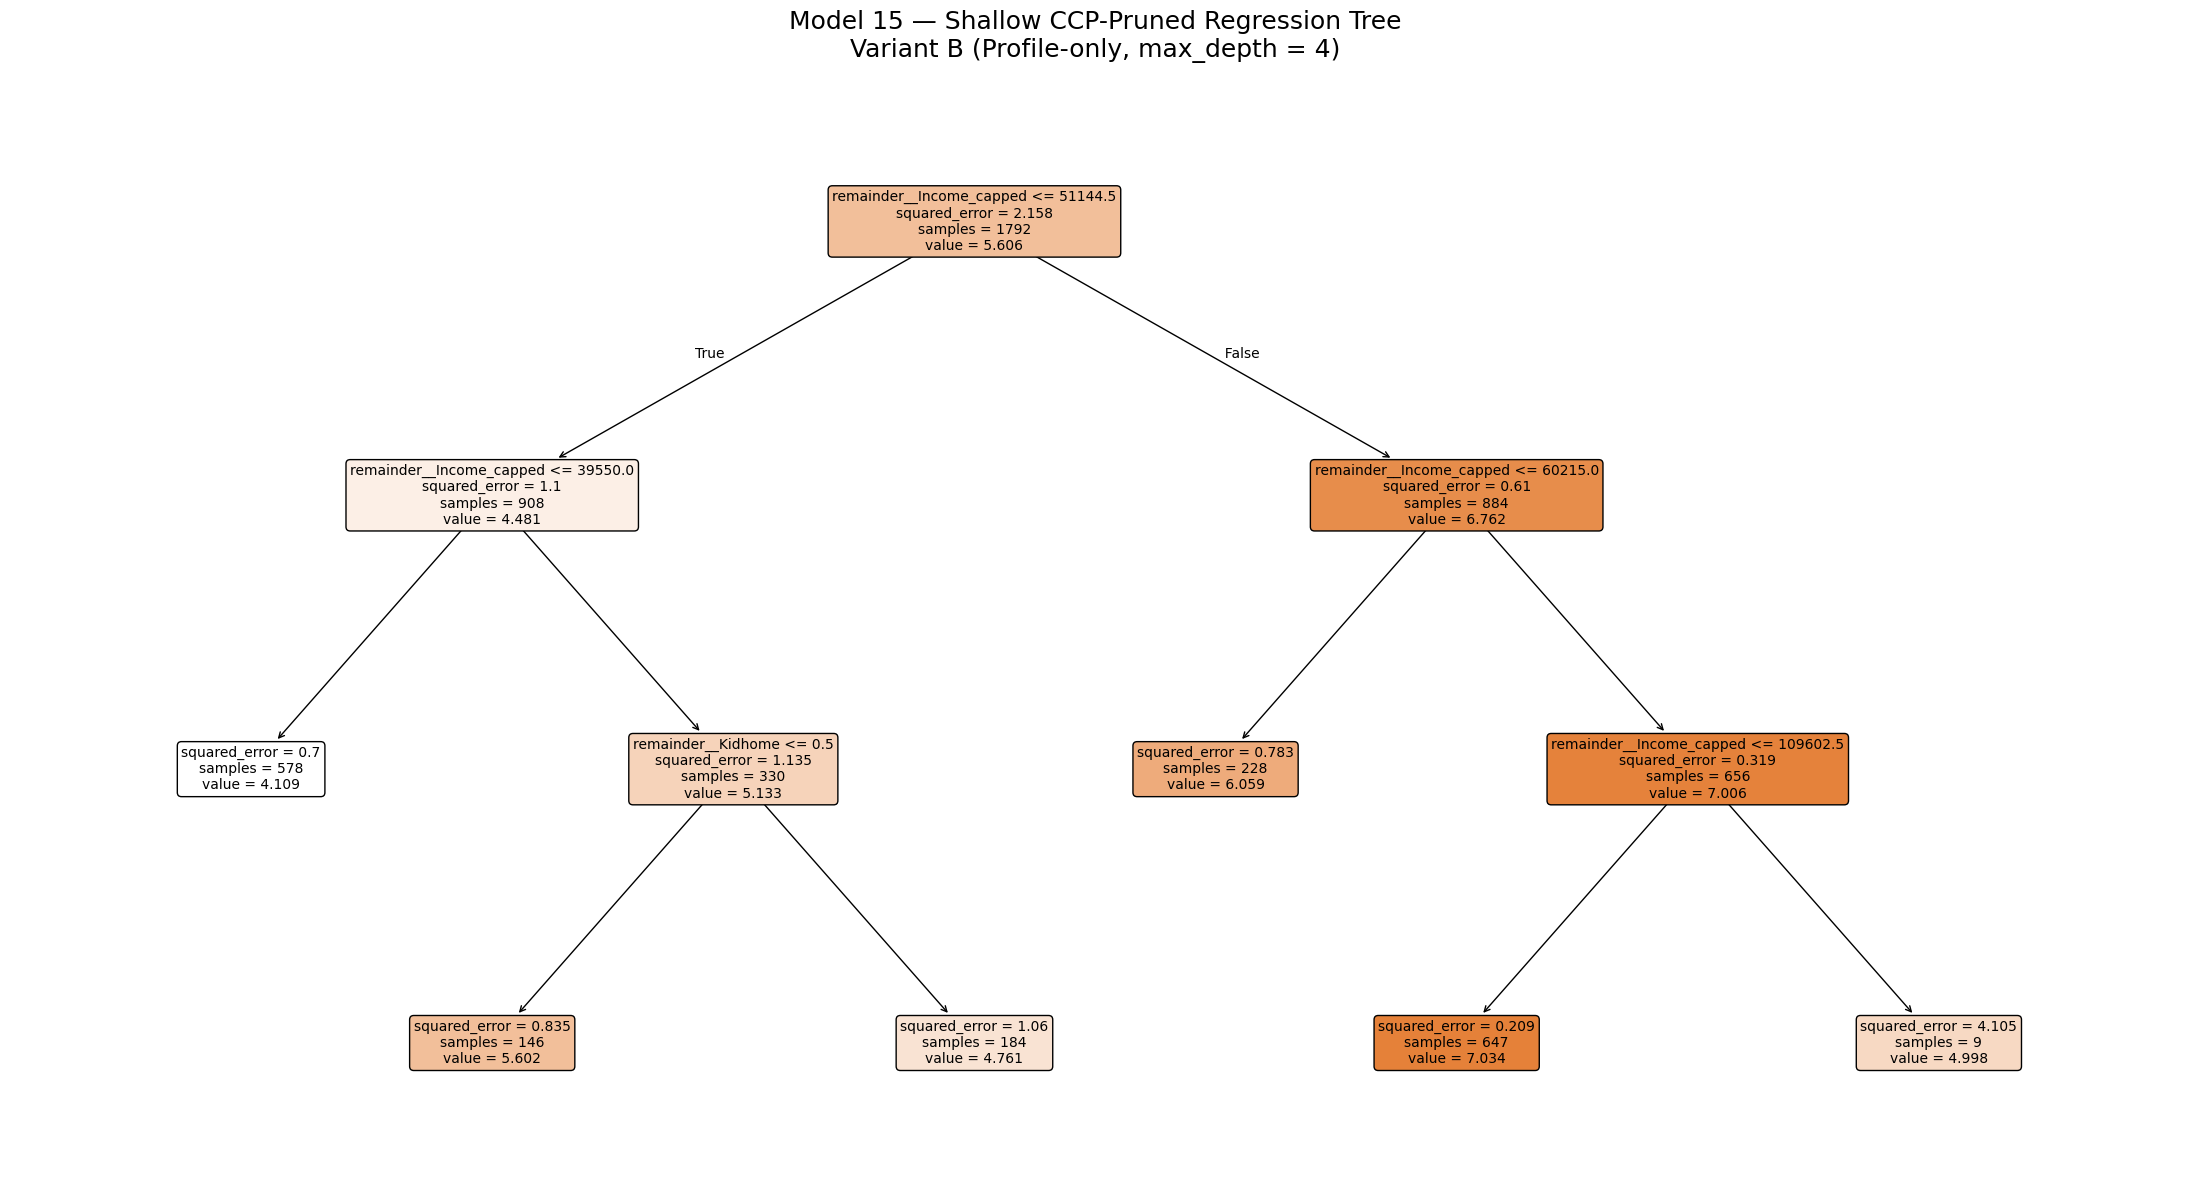

In [228]:
# ============================================================
# Optional — Visualize a shallow version of Model 15
# Variant B: Profile-only feature set
# ============================================================

from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Get fitted preprocessor and tree from Model 15 (Variant B)
# ------------------------------------------------------------
prep = pipe_tree.named_steps["pre"]
tree_final = pipe_tree.named_steps["tree"]

# Feature names after preprocessing (numeric + OHE)
feature_names = prep.get_feature_names_out()

# ------------------------------------------------------------
# 2) Build a shallow tree using SAME ccp_alpha (Variant B)
# ------------------------------------------------------------
shallow_tree = DecisionTreeRegressor(
    random_state=42,
    ccp_alpha=tree_final.ccp_alpha,  # = 0.008489
    max_depth=4                      # force interpretability
)

# ------------------------------------------------------------
# 3) Fit shallow tree on PREPROCESSED training data
# ------------------------------------------------------------
X_train_trans = prep.transform(X_train_m15)
shallow_tree.fit(X_train_trans, y_train_m15)

# ------------------------------------------------------------
# 4) Plot the shallow tree
# ------------------------------------------------------------
plt.figure(figsize=(22, 12))
plot_tree(
    shallow_tree,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title(
    "Model 15 — Shallow CCP-Pruned Regression Tree\n"
    "Variant B (Profile-only, max_depth = 4)",
    fontsize=18,
    pad=20
)

plt.tight_layout()
plt.show()


## 6.Ensemble Tree-Based Models
Single decision trees are interpretable but prone to overfitting and instability.
Ensemble tree-based models combine multiple trees to improve robustness and
generalization.

In this section, ensemble methods are introduced using the same leakage-safe
framework and feature variants (A and B) as before.

### Model 16 — Base Random Forest Regressor

(200 trees, OOB, leakage-safe)

#### 🔹 Variant A — Profile + Behavioral feature set

In [229]:
# ============================================================
# Model 16 — Base Random Forest (Behavioral features)
# ============================================================

# ------------------------------------------------------------
# Features — Variant A (Behavioral)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Tenure_Days",
    "Recency",
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

cat_cols = [
    "Education",
    "Marital_Status",
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

X_train_m16 = X_train[num_cols + cat_cols]
X_test_m16  = X_test[num_cols + cat_cols]

y_train_m16 = y_train_log
y_test_m16  = y_test_log

# ------------------------------------------------------------
# Preprocessing (OHE only for categorical)
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=200,
    oob_score=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

pipe_rf = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("rf", rf)
    ]
)

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_rf.fit(X_train_m16, y_train_m16)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_rf.predict(X_train_m16)
y_test_pred  = pipe_rf.predict(X_test_m16)

r2_train = r2_score(y_train_m16, y_train_pred)
r2_test  = r2_score(y_test_m16, y_test_pred)
mse_train = mean_squared_error(y_train_m16, y_train_pred)
mse_test  = mean_squared_error(y_test_m16, y_test_pred)
oob_r2 = pipe_rf.named_steps["rf"].oob_score_

# ------------------------------------------------------------
# Feature count (AFTER preprocessing)
# ------------------------------------------------------------
feature_count = len(
    pipe_rf
    .named_steps["pre"]
    .get_feature_names_out()
)

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 16 — Base Random Forest",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=oob_r2,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="200 trees, OOB score, OHE-expanded feature space"
)

print("Model 16 — Base Random Forest")
print(f"OOB R²   : {oob_r2:.3f}")
print(f"R² test  : {r2_test:.3f}")
print(f"R² train : {r2_train:.3f}")


Model 16 — Base Random Forest
OOB R²   : 0.960
R² test  : 0.961
R² train : 0.995


#### 🔹 Variant B — Profile-only feature set

In [230]:
# ============================================================
# Model 16 — Base Random Forest (Profile-only)
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# ------------------------------------------------------------
# Features — Variant B (Profile-only)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Kidhome",
    "Teenhome"
]

cat_cols = [
    "Education",
    "Marital_Status"
]

X_train_m16 = X_train[num_cols + cat_cols]
X_test_m16  = X_test[num_cols + cat_cols]

y_train_m16 = y_train_log
y_test_m16  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=200,
    oob_score=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

pipe_rf = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("rf", rf)
    ]
)

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_rf.fit(X_train_m16, y_train_m16)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_rf.predict(X_train_m16)
y_test_pred  = pipe_rf.predict(X_test_m16)

r2_train = r2_score(y_train_m16, y_train_pred)
r2_test  = r2_score(y_test_m16, y_test_pred)
mse_train = mean_squared_error(y_train_m16, y_train_pred)
mse_test  = mean_squared_error(y_test_m16, y_test_pred)
oob_r2 = pipe_rf.named_steps["rf"].oob_score_

# ------------------------------------------------------------
# Feature count (AFTER preprocessing)
# ------------------------------------------------------------
feature_count = len(
    pipe_rf
    .named_steps["pre"]
    .get_feature_names_out()
)

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_profile_model(
    name="Model 16 — Base Random Forest",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=oob_r2,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="200 trees, OOB score, OHE-expanded feature space"
)


print("Model 16 — Base Random Forest")
print(f"OOB R²   : {oob_r2:.3f}")
print(f"R² test  : {r2_test:.3f}")
print(f"R² train : {r2_train:.3f}")


Model 16 — Base Random Forest
OOB R²   : 0.731
R² test  : 0.731
R² train : 0.963


### Model 17 — Tuned Random Forest Regressor (GridSearchCV)

#### 🔹 Variant A — Profile + Behavioral feature set

In [231]:
# ============================================================
# Model 17 — Tuned Random Forest (Behavioral)
# ============================================================

# ------------------------------------------------------------
# Features (BEHAVIORAL)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Tenure_Days",
    "Recency",
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

cat_cols = [
    "Education",
    "Marital_Status",
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

X_train_m17 = X_train[num_cols + cat_cols]
X_test_m17  = X_test[num_cols + cat_cols]

y_train_m17 = y_train_log
y_test_m17  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# Base Random Forest
# ------------------------------------------------------------
rf = RandomForestRegressor(
    n_estimators=200,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

pipe_rf = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("rf", rf)
    ]
)

# ------------------------------------------------------------
# Hyperparameter grid
# ------------------------------------------------------------
param_grid = {
    "rf__max_depth": [None, 10, 15, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe_rf,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
grid.fit(X_train_m17, y_train_m17)

best_model = grid.best_estimator_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train_m17)
y_test_pred  = best_model.predict(X_test_m17)

r2_train = r2_score(y_train_m17, y_train_pred)
r2_test  = r2_score(y_test_m17, y_test_pred)
mse_train = mean_squared_error(y_train_m17, y_train_pred)
mse_test  = mean_squared_error(y_test_m17, y_test_pred)

oob_r2 = best_model.named_steps["rf"].oob_score_

# feature count AFTER OHE
feature_count = len(
    best_model.named_steps["pre"].get_feature_names_out()
)

# ------------------------------------------------------------
#  Report
# ------------------------------------------------------------
forest = best_model.named_steps["rf"]

best_params = grid.best_params_
best_cv_r2  = grid.best_score_
oob_r2      = forest.oob_score_

# diagnostics (average over trees)
tree_depths = [est.tree_.max_depth for est in forest.estimators_]
leaf_counts = [(est.tree_.children_left == -1).sum() for est in forest.estimators_]

mean_depth  = float(np.mean(tree_depths))
mean_leaves = float(np.mean(leaf_counts))

print("🌲 Model 17 — Tuned Random Forest (GridSearchCV)")
print(f"Best params:                 {best_params}")
print(f"OOB R²:                      {oob_r2:.3f}")
print(f"R² (train):                  {r2_train:.3f}")
print(f"R² (test):                   {r2_test:.3f}")
print(f"Best CV R² (5-fold):         {best_cv_r2:.3f}")
print(f"MSE (train):                 {mse_train:.3f}")
print(f"MSE (test):                  {mse_test:.3f}")
print(f"Mean tree depth:             {mean_depth:.1f}")
print(f"Mean leaf nodes per tree:    {mean_leaves:.1f}")
print(f"Total features after OHE:    {feature_count}")

# ------------------------------------------------------------
# Log
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 17 — Tuned Random Forest",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=grid.best_score_,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes=f"OOB R²={oob_r2:.3f}, GridSearchCV"
)


🌲 Model 17 — Tuned Random Forest (GridSearchCV)
Best params:                 {'rf__max_depth': 20, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2}
OOB R²:                      0.961
R² (train):                  0.991
R² (test):                   0.962
Best CV R² (5-fold):         0.960
MSE (train):                 0.019
MSE (test):                  0.083
Mean tree depth:             18.1
Mean leaf nodes per tree:    491.7
Total features after OHE:    27


#### 🌲 Feature Importance + Barplot Variant A — Behavioral (Model 17A)

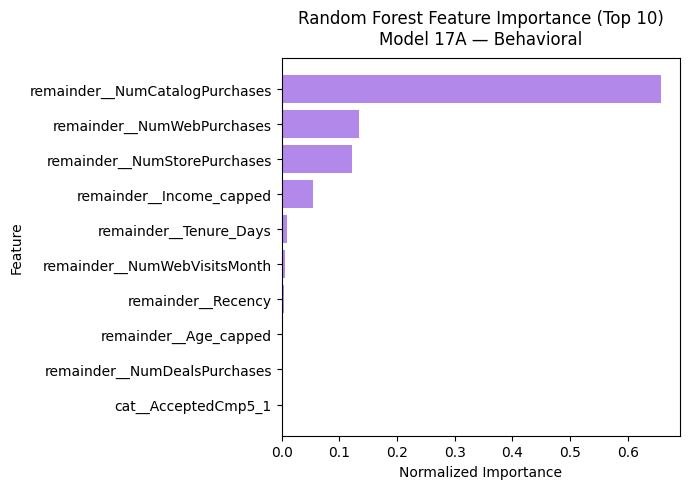

In [232]:
# ============================================================
# 🌲 Feature Importance — Random Forest (Variant A: Behavioral)
# Model 17A
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Get preprocessor & forest
# ------------------------------------------------------------
preprocessor_A = best_model.named_steps["pre"]
forest_A = best_model.named_steps["rf"]

# ------------------------------------------------------------
# Feature names & importances
# ------------------------------------------------------------
feature_names_A = preprocessor_A.get_feature_names_out()
importances_A = forest_A.feature_importances_

feat_imp_A = (
    pd.DataFrame({
        "feature": feature_names_A,
        "importance": importances_A
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feat_imp_A["importance_norm"] = (
    feat_imp_A["importance"] / feat_imp_A["importance"].sum()
)

# ------------------------------------------------------------
# Barplot (Top K)
# ------------------------------------------------------------
TOP_K = 10
top_feat_A = feat_imp_A.head(TOP_K).iloc[::-1]

plt.figure(figsize=(7, 5))
plt.barh(top_feat_A["feature"], top_feat_A["importance_norm"], color = "#B388EB")
plt.title(
    "Random Forest Feature Importance (Top 10)\nModel 17A — Behavioral",
    pad=10
)
plt.xlabel("Normalized Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


#### 🔹 Variant B — Profile-only feature set

In [233]:
# ============================================================
# Model 17 — Tuned Random Forest (Profile-only)
# ============================================================

# ------------------------------------------------------------
# Features (PROFILE-ONLY)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Kidhome",
    "Teenhome"
]

cat_cols = [
    "Education",
    "Marital_Status"
]

X_train_m17 = X_train[num_cols + cat_cols]
X_test_m17  = X_test[num_cols + cat_cols]

y_train_m17 = y_train_log
y_test_m17  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough"
)

rf = RandomForestRegressor(
    n_estimators=200,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

pipe_rf = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("rf", rf)
    ]
)

param_grid = {
    "rf__max_depth": [None, 8, 12, 16],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe_rf,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
grid.fit(X_train_m17, y_train_m17)

best_model = grid.best_estimator_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train_m17)
y_test_pred  = best_model.predict(X_test_m17)

r2_train = r2_score(y_train_m17, y_train_pred)
r2_test  = r2_score(y_test_m17, y_test_pred)
mse_train = mean_squared_error(y_train_m17, y_train_pred)
mse_test  = mean_squared_error(y_test_m17, y_test_pred)

oob_r2 = best_model.named_steps["rf"].oob_score_

feature_count = len(
    best_model.named_steps["pre"].get_feature_names_out()
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
forest = best_model.named_steps["rf"]

best_params = grid.best_params_
best_cv_r2  = grid.best_score_
oob_r2      = forest.oob_score_

# diagnostics (average over trees)
tree_depths = [est.tree_.max_depth for est in forest.estimators_]
leaf_counts = [(est.tree_.children_left == -1).sum() for est in forest.estimators_]

mean_depth  = float(np.mean(tree_depths))
mean_leaves = float(np.mean(leaf_counts))

print("🌲 Model 17 — Tuned Random Forest(GridSearchCV)")
print(f"Best params:                 {best_params}")
print(f"OOB R²:                      {oob_r2:.3f}")
print(f"R² (train):                  {r2_train:.3f}")
print(f"R² (test):                   {r2_test:.3f}")
print(f"Best CV R² (5-fold):         {best_cv_r2:.3f}")
print(f"MSE (train):                 {mse_train:.3f}")
print(f"MSE (test):                  {mse_test:.3f}")
print(f"Mean tree depth:             {mean_depth:.1f}")
print(f"Mean leaf nodes per tree:    {mean_leaves:.1f}")
print(f"Total features after OHE:    {feature_count}")


# ------------------------------------------------------------
# Log
# ------------------------------------------------------------
log_profile_model(
    name="Model 17 — Tuned Random Forest",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=grid.best_score_,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes=f"OOB R²={oob_r2:.3f}, GridSearchCV"
)


🌲 Model 17 — Tuned Random Forest(GridSearchCV)
Best params:                 {'rf__max_depth': 8, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2}
OOB R²:                      0.745
R² (train):                  0.842
R² (test):                   0.741
Best CV R² (5-fold):         0.739
MSE (train):                 0.342
MSE (test):                  0.563
Mean tree depth:             8.0
Mean leaf nodes per tree:    111.5
Total features after OHE:    13


#### 🌲 Feature Importance + Barplot Variant B — Profile-only (Model 17B)

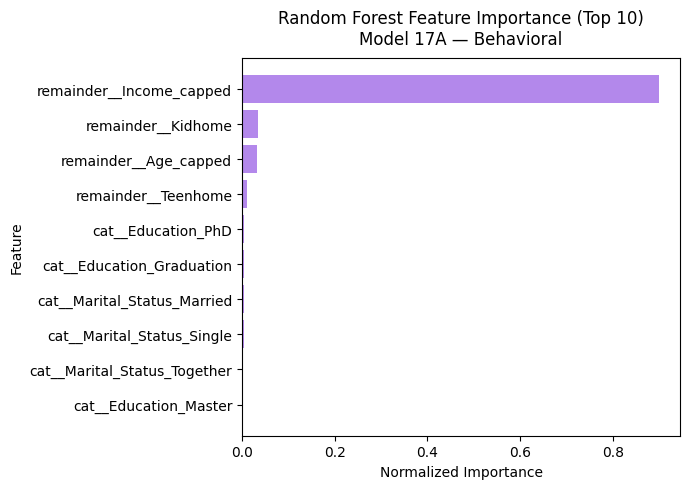

In [234]:
# ============================================================
# 🌲 Feature Importance — Random Forest (Variant A: Behavioral)
# Model 17A
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Get preprocessor & forest
# ------------------------------------------------------------
preprocessor_A = best_model.named_steps["pre"]
forest_A = best_model.named_steps["rf"]

# ------------------------------------------------------------
# Feature names & importances
# ------------------------------------------------------------
feature_names_A = preprocessor_A.get_feature_names_out()
importances_A = forest_A.feature_importances_

feat_imp_A = (
    pd.DataFrame({
        "feature": feature_names_A,
        "importance": importances_A
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feat_imp_A["importance_norm"] = (
    feat_imp_A["importance"] / feat_imp_A["importance"].sum()
)

# ------------------------------------------------------------
# Barplot (Top K)
# ------------------------------------------------------------
TOP_K = 10
top_feat_A = feat_imp_A.head(TOP_K).iloc[::-1]

plt.figure(figsize=(7, 5))
plt.barh(top_feat_A["feature"], top_feat_A["importance_norm"], color = "#B388EB")
plt.title(
    "Random Forest Feature Importance (Top 10)\nModel 17A — Behavioral",
    pad=10
)
plt.xlabel("Normalized Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Model 18 — Gradient Boosting Regressor (Baseline)

#### 🔹 Variant A — Profile + Behavioral feature set

In [235]:
# ============================================================
# Model 18 — Gradient Boosting Regressor
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Features (BEHAVIORAL)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Tenure_Days",
    "Recency",
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

cat_cols = [
    "Education",
    "Marital_Status",
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

X_train_m18 = X_train[num_cols + cat_cols]
X_test_m18  = X_test[num_cols + cat_cols]

y_train_m18 = y_train_log
y_test_m18  = y_test_log

# ------------------------------------------------------------
# Preprocessing (OHE only for categoricals)
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# Gradient Boosting (baseline)
# ------------------------------------------------------------
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=1.0,
    random_state=42
)

pipe_gbr = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("gbr", gbr)
    ]
)

# ------------------------------------------------------------
# CV (train only)
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = cross_val_score(
    pipe_gbr, X_train_m18, y_train_m18, cv=cv, scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_gbr.fit(X_train_m18, y_train_m18)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_gbr.predict(X_train_m18)
y_test_pred  = pipe_gbr.predict(X_test_m18)

r2_train = r2_score(y_train_m18, y_train_pred)
r2_test  = r2_score(y_test_m18, y_test_pred)
mse_train = mean_squared_error(y_train_m18, y_train_pred)
mse_test  = mean_squared_error(y_test_m18, y_test_pred)

# ------------------------------------------------------------
# Feature count AFTER preprocessing (correct)
# ------------------------------------------------------------
feature_names = (
    pipe_gbr
    .named_steps["pre"]
    .get_feature_names_out()
)

feature_count = len(feature_names)
# --

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 18 — Gradient Boosting",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Baseline Gradient Boosting, behavioral features"
)

print("Model 18 — Gradient Boosting")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 18 — Gradient Boosting
R² test : 0.961
R² train: 0.979
R² CV   : 0.958


#### 🔹 Variant B — Profile-only feature set

In [236]:
# ============================================================
# Model 18 — Gradient Boosting Regressor
# Variant B: Profile-only feature set
# ============================================================

# ------------------------------------------------------------
# Features (PROFILE-ONLY)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Kidhome",
    "Teenhome"
]

cat_cols = [
    "Education",
    "Marital_Status"
]

X_train_m18 = X_train[num_cols + cat_cols]
X_test_m18  = X_test[num_cols + cat_cols]

y_train_m18 = y_train_log
y_test_m18  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# Gradient Boosting (baseline)
# ------------------------------------------------------------
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=1.0,
    random_state=42
)

pipe_gbr = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("gbr", gbr)
    ]
)

# ------------------------------------------------------------
# CV (train only)
# ------------------------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = cross_val_score(
    pipe_gbr, X_train_m18, y_train_m18, cv=cv, scoring="r2"
).mean()

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
pipe_gbr.fit(X_train_m18, y_train_m18)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = pipe_gbr.predict(X_train_m18)
y_test_pred  = pipe_gbr.predict(X_test_m18)

r2_train = r2_score(y_train_m18, y_train_pred)
r2_test  = r2_score(y_test_m18, y_test_pred)
mse_train = mean_squared_error(y_train_m18, y_train_pred)
mse_test  = mean_squared_error(y_test_m18, y_test_pred)

# ------------------------------------------------------------
# Feature count AFTER preprocessing (correct)
# ------------------------------------------------------------
feature_names = (
    pipe_gbr
    .named_steps["pre"]
    .get_feature_names_out()
)

feature_count = len(feature_names)
# ------------------------------------------------------------

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_profile_model(
    name="Model 18 — Gradient Boosting",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="Baseline Gradient Boosting, profile-only features"
)

print("Model 18 — Gradient Boosting")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 18 — Gradient Boosting
R² test : 0.736
R² train: 0.808
R² CV   : 0.740


### Model 19 — XGBoost Regressor (Tuned, CV)

#### 🔹 Variant A — Profile + Behavioral feature set

In [237]:
# ============================================================
# Model 19 — XGBoost Regressor
# Variant A: Behavioral feature set
# ============================================================

# ------------------------------------------------------------
# Features (Behavioral)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Tenure_Days",
    "Recency",
    "Kidhome",
    "Teenhome",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

cat_cols = [
    "Education",
    "Marital_Status",
    "Complain",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

X_train_m19 = X_train[num_cols + cat_cols]
X_test_m19  = X_test[num_cols + cat_cols]

y_train_m19 = y_train_log
y_test_m19  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# ------------------------------------------------------------
# XGBoost + GridSearchCV
# ------------------------------------------------------------
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

pipe_xgb = Pipeline([
    ("pre", preprocessor),
    ("xgb", xgb)
])

param_grid = {
    "xgb__n_estimators": [300, 500],
    "xgb__max_depth": [3, 5],
    "xgb__learning_rate": [0.05, 0.1],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe_xgb,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
grid.fit(X_train_m19, y_train_m19)

best_model = grid.best_estimator_
best_cv = grid.best_score_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train_m19)
y_test_pred  = best_model.predict(X_test_m19)

r2_train = r2_score(y_train_m19, y_train_pred)
r2_test  = r2_score(y_test_m19, y_test_pred)
mse_train = mean_squared_error(y_train_m19, y_train_pred)
mse_test  = mean_squared_error(y_test_m19, y_test_pred)

# ------------------------------------------------------------
# Feature count AFTER preprocessing (correct)
# ------------------------------------------------------------
feature_names = (
    pipe_gbr
    .named_steps["pre"]
    .get_feature_names_out()
)

feature_count = len(feature_names)
# ------------------------------------------------------------

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 19 — XGBoost",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=best_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="XGBoost, tuned, behavioral feature set"
)

print("Model 19 — XGBoost")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {best_cv:.3f}")


Model 19 — XGBoost
R² test : 0.966
R² train: 0.997
R² CV   : 0.967


#### 🔹 Variant B — Profile-only feature set

In [238]:
# ============================================================
# Model 19 — XGBoost Regressor
# Variant B: Profile-only feature set
# ============================================================

num_cols = [
    "Income_capped",
    "Age_capped",
    "Kidhome",
    "Teenhome"
]

cat_cols = [
    "Education",
    "Marital_Status"
]

X_train_m19 = X_train[num_cols + cat_cols]
X_test_m19  = X_test[num_cols + cat_cols]

y_train_m19 = y_train_log
y_test_m19  = y_test_log

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

pipe_xgb = Pipeline([
    ("pre", preprocessor),
    ("xgb", xgb)
])

param_grid = {
    "xgb__n_estimators": [200, 400],
    "xgb__max_depth": [2, 3],
    "xgb__learning_rate": [0.05, 0.1],
    "xgb__subsample": [0.8, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe_xgb,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_m19, y_train_m19)

best_model = grid.best_estimator_
best_cv = grid.best_score_

y_train_pred = best_model.predict(X_train_m19)
y_test_pred  = best_model.predict(X_test_m19)

r2_train = r2_score(y_train_m19, y_train_pred)
r2_test  = r2_score(y_test_m19, y_test_pred)
mse_train = mean_squared_error(y_train_m19, y_train_pred)
mse_test  = mean_squared_error(y_test_m19, y_test_pred)

# ------------------------------------------------------------
# Feature count AFTER preprocessing (correct)
# ------------------------------------------------------------
feature_names = (
    pipe_gbr
    .named_steps["pre"]
    .get_feature_names_out()
)

feature_count = len(feature_names)
# ------------------------------------------------------------

log_profile_model(
    name="Model 19 — XGBoost",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=best_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="XGBoost, tuned, profile-only features"
)

print("Model 19 — XGBoost")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {best_cv:.3f}")


Model 19 — XGBoost
R² test : 0.740
R² train: 0.779
R² CV   : 0.742


## 5. Kernel-Based Model

### Model 20 — SVR (RBF)(Lasso-selected features)

#### 🔹 Variant A — Profile + Behavioral feature set

In [239]:
# ============================================================
# Model 20 — SVR (RBF)
# Variant A: Behavioral (Lasso-selected features)
# ============================================================

# ------------------------------------------------------------
# Features (BEHAVIORAL — Lasso-selected)
# ------------------------------------------------------------
num_cols = [
    "NumCatalogPurchases",
    "Income_capped",
    "NumWebPurchases",
    "NumStorePurchases",
    "Kidhome",
    "NumDealsPurchases",
    "Teenhome",
    "Tenure_Days",
]

X_train_m20 = X_train[num_cols]
X_test_m20  = X_test[num_cols]

y_train_m20 = y_train_log
y_test_m20  = y_test_log

# ------------------------------------------------------------
# Preprocessing (scaling REQUIRED for SVR)
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
    ]
)

# ------------------------------------------------------------
# SVR pipeline
# ------------------------------------------------------------
pipe_svr = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("svr", SVR(kernel="rbf")),
    ]
)

# ------------------------------------------------------------
# GridSearchCV
# ------------------------------------------------------------
param_grid = {
    "svr__C": [0.1, 1, 10],
    "svr__gamma": ["scale", 0.1, 0.01],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe_svr,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
grid.fit(X_train_m20, y_train_m20)

best_model = grid.best_estimator_
r2_cv = grid.best_score_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train_m20)
y_test_pred  = best_model.predict(X_test_m20)

r2_train = r2_score(y_train_m20, y_train_pred)
r2_test  = r2_score(y_test_m20, y_test_pred)
mse_train = mean_squared_error(y_train_m20, y_train_pred)
mse_test  = mean_squared_error(y_test_m20, y_test_pred)

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 20 — SVR (RBF on Lasso-selected features)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=len(num_cols),
    notes="SVR with RBF kernel on Lasso-selected behavioral features"
)

print("Model 20 — SVR (RBF on Lasso-selected features)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 20 — SVR (RBF on Lasso-selected features)
R² test : 0.964
R² train: 0.973
R² CV   : 0.949


#### 🔹 Variant B — Profile-only feature set

In [240]:
# ============================================================
# Model 20 — SVR (RBF)
# Variant B: Profile-only
# ============================================================

# ------------------------------------------------------------
# Features (PROFILE-ONLY)
# ------------------------------------------------------------
num_cols = [
    "Income_capped",
    "Age_capped",
    "Kidhome",
    "Teenhome",
]

X_train_m20 = X_train[num_cols]
X_test_m20  = X_test[num_cols]

y_train_m20 = y_train_log
y_test_m20  = y_test_log

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
    ]
)

pipe_svr = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("svr", SVR(kernel="rbf")),
    ]
)

param_grid = {
    "svr__C": [0.1, 1, 10],
    "svr__gamma": ["scale", 0.1, 0.01],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe_svr,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------
grid.fit(X_train_m20, y_train_m20)

best_model = grid.best_estimator_
r2_cv = grid.best_score_

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train_m20)
y_test_pred  = best_model.predict(X_test_m20)

r2_train = r2_score(y_train_m20, y_train_pred)
r2_test  = r2_score(y_test_m20, y_test_pred)
mse_train = mean_squared_error(y_train_m20, y_train_pred)
mse_test  = mean_squared_error(y_test_m20, y_test_pred)

# ------------------------------------------------------------
# Log + Print
# ------------------------------------------------------------
log_profile_model(
    name="Model 20 — SVR (RBF on Lasso-selected features)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=len(num_cols),
    notes="SVR with RBF kernel on profile-only features"
)

print("Model 20 — SVR (RBF on Lasso-selected features)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")


Model 20 — SVR (RBF on Lasso-selected features)
R² test : 0.742
R² train: 0.761
R² CV   : 0.749


### Model 21 — SVR (RBF)(on Polynomial Lasso–selected features)

#### 🔹 Variant A — Profile + Behavioral feature set

In [241]:
# ============================================================
# Model 21 — SVR (RBF)
# Variant A: Polynomial Lasso-selected (Behavioral)
# ============================================================

# ------------------------------------------------------------
# 1) Polynomial feature space (from Model 10A)
# ------------------------------------------------------------
X_train_poly = (
    pipe_lasso_poly_fixed_behavioral
    .named_steps["pre"]
    .transform(X_train_m10_A)
)

X_test_poly = (
    pipe_lasso_poly_fixed_behavioral
    .named_steps["pre"]
    .transform(X_test_m10_A)
)

feature_names_poly = (
    pipe_lasso_poly_fixed_behavioral
    .named_steps["pre"]
    .get_feature_names_out()
)

# ------------------------------------------------------------
# 2) Select polynomial features kept by Lasso
# ------------------------------------------------------------
coefs = pipe_lasso_poly_fixed_behavioral.named_steps["lasso"].coef_

selected_idx = [i for i, c in enumerate(coefs) if abs(c) > 1e-8]

X_train_sel = X_train_poly[:, selected_idx]
X_test_sel  = X_test_poly[:, selected_idx]

feature_count = len(selected_idx)

y_train_m21 = y_train_log
y_test_m21  = y_test_log

# ------------------------------------------------------------
# 3) Scaling (SVR requires scaling)
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)

# ------------------------------------------------------------
# 4) SVR + GridSearchCV
# ------------------------------------------------------------
svr = SVR(kernel="rbf")

param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.1, 0.01],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    svr,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# 5) Fit
# ------------------------------------------------------------
grid.fit(X_train_scaled, y_train_m21)

best_model = grid.best_estimator_
r2_cv = grid.best_score_

# ------------------------------------------------------------
# 6) Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred  = best_model.predict(X_test_scaled)

r2_train = r2_score(y_train_m21, y_train_pred)
r2_test  = r2_score(y_test_m21, y_test_pred)
mse_train = mean_squared_error(y_train_m21, y_train_pred)
mse_test  = mean_squared_error(y_test_m21, y_test_pred)

# ------------------------------------------------------------
# 7) Log + Print
# ------------------------------------------------------------
log_behavioral_model(
    name="Model 21 — SVR (Poly Lasso-selected features)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="SVR (RBF) on polynomial features selected by Lasso (Model 10A)"
)

print("Model 21 — SVR (Poly Lasso-selected features)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"Final feature count: {feature_count}")


Model 21 — SVR (Poly Lasso-selected features)
R² test : 0.965
R² train: 0.966
R² CV   : 0.953
Final feature count: 21


#### 🔹 Variant B — Profile-only feature set

In [242]:
# ============================================================
# Model 21 — SVR (RBF)
# Variant B: Polynomial Lasso-selected (Profile-only)
# ============================================================

# ------------------------------------------------------------
# 1) Polynomial feature space (from Model 10B)
# ------------------------------------------------------------
X_train_poly = (
    pipe_lasso_poly_fixed_profile
    .named_steps["pre"]
    .transform(X_train_m10_B)
)

X_test_poly = (
    pipe_lasso_poly_fixed_profile
    .named_steps["pre"]
    .transform(X_test_m10_B)
)

feature_names_poly = (
    pipe_lasso_poly_fixed_profile
    .named_steps["pre"]
    .get_feature_names_out()
)

# ------------------------------------------------------------
# 2) Select polynomial features kept by Lasso
# ------------------------------------------------------------
coefs = pipe_lasso_poly_fixed_profile.named_steps["lasso"].coef_

selected_idx = [i for i, c in enumerate(coefs) if abs(c) > 1e-8]

X_train_sel = X_train_poly[:, selected_idx]
X_test_sel  = X_test_poly[:, selected_idx]

feature_count = len(selected_idx)

y_train_m21 = y_train_log
y_test_m21  = y_test_log

# ------------------------------------------------------------
# 3) Scaling
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)

# ------------------------------------------------------------
# 4) SVR + GridSearchCV
# ------------------------------------------------------------
svr = SVR(kernel="rbf")

param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.1, 0.01],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    svr,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

# ------------------------------------------------------------
# 5) Fit
# ------------------------------------------------------------
grid.fit(X_train_scaled, y_train_m21)

best_model = grid.best_estimator_
r2_cv = grid.best_score_

# ------------------------------------------------------------
# 6) Metrics
# ------------------------------------------------------------
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred  = best_model.predict(X_test_scaled)

r2_train = r2_score(y_train_m21, y_train_pred)
r2_test  = r2_score(y_test_m21, y_test_pred)
mse_train = mean_squared_error(y_train_m21, y_train_pred)
mse_test  = mean_squared_error(y_test_m21, y_test_pred)

# ------------------------------------------------------------
# 7) Log + Print
# ------------------------------------------------------------
log_profile_model(
    name="Model 21 — SVR (Poly Lasso-selected features)",
    r2_train=r2_train,
    r2_test=r2_test,
    r2_cv=r2_cv,
    mse_train=mse_train,
    mse_test=mse_test,
    feature_count=feature_count,
    notes="SVR (RBF) on polynomial features selected by Lasso (Model 10B)"
)

print("Model 21 — SVR (Poly Lasso-selected features)")
print(f"R² test : {r2_test:.3f}")
print(f"R² train: {r2_train:.3f}")
print(f"R² CV   : {r2_cv:.3f}")
print(f"Final feature count: {feature_count}")


Model 21 — SVR (Poly Lasso-selected features)
R² test : 0.750
R² train: 0.762
R² CV   : 0.748
Final feature count: 6


### 📋 Final Summary — Behavioral Regression Models

#### Table 1 — Behavioral Regression Models in Order of Development

In [243]:
# ============================================
# 📋 Regression Models – Behavioral Summary
# ============================================

import pandas as pd

df_behavioral = pd.DataFrame(behavioral_log)

summary_cols = [
    "Model",
    "R²_train",
    "R²_test",
    "R²_CV",
    "MSE_test",
    "MSE_train",
    "Feature_count"
]

df_behavioral = df_behavioral[summary_cols]

print("📊 Behavioral Models Summary:")
display(df_behavioral)


📊 Behavioral Models Summary:


,Model,R²_train,R²_test,R²_CV,MSE_test,MSE_train,Feature_count
0,Model 1 — Linear Regression(Baseline),0.873,0.892,0.865,0.23,0.27,27
1,Model 2 — Linear Regression (EDA-based features),0.861,0.878,0.854,0.26,0.30,21
2,Model 3 — Ridge Regression,0.872,0.891,0.867,0.24,0.28,27
3,Model 4 — LassoCV,0.873,0.892,0.867,0.24,0.28,18
4,Model 5 — LassoCV (Fixed Alpha),0.866,0.884,0.863,0.25,0.29,8
5,Model 6 — Linear Regression (Lasso-selected),0.868,0.889,0.865,0.24,0.28,8
6,Model 7 — Polynomial Linear Regression,0.961,0.900,0.948,0.22,0.08,93
7,Model 8 — Polynomial Ridge Regression,0.961,0.907,0.948,0.20,0.08,93
8,Model 9 — Polynomial LassoCV,0.961,0.909,0.946,0.20,0.08,90
9,Model 10 — Polynomial Lasso (fixed α),0.929,0.938,0.925,0.13,0.15,21


#### Table 2 — Behavioral Models Ranked by Test R² (Color-Coded by Model Family)

📋 behavioral-only Models — Sorted by R²_test


,Model,R²_train,R²_test,R²_CV,MSE_test,MSE_train,Feature_count,model_id,Model_Family
0,Model 19 — XGBoost,0.997,0.966,0.967,0.07,0.01,13,19,4. Ensemble Tree-Based
1,Model 21 — SVR (Poly Lasso-selected features),0.966,0.965,0.953,0.08,0.07,21,21,5. Kernel-Based
2,Model 20 — SVR (RBF on Lasso-selected features),0.973,0.964,0.949,0.08,0.06,8,20,5. Kernel-Based
3,Model 17 — Tuned Random Forest,0.991,0.962,0.960,0.08,0.02,27,17,4. Ensemble Tree-Based
4,Model 18 — Gradient Boosting,0.979,0.961,0.958,0.08,0.05,27,18,4. Ensemble Tree-Based
5,Model 16 — Base Random Forest,0.995,0.961,0.960,0.08,0.01,27,16,4. Ensemble Tree-Based
6,Model 13 — Tuned Regression Tree,0.969,0.950,0.946,0.11,0.07,27,13,3. Decision Tree
7,Model 15 — Regression Tree (Fixed CCP),0.975,0.948,0.936,0.11,0.05,27,15,3. Decision Tree
8,Model 14 — Regression Tree (CCP Pruned),0.975,0.948,0.936,0.11,0.05,27,14,3. Decision Tree
9,Model 11 — Linear Regression (Poly Lasso-selec...,0.946,0.948,0.942,0.11,0.12,21,11,2. Polynomial Regression


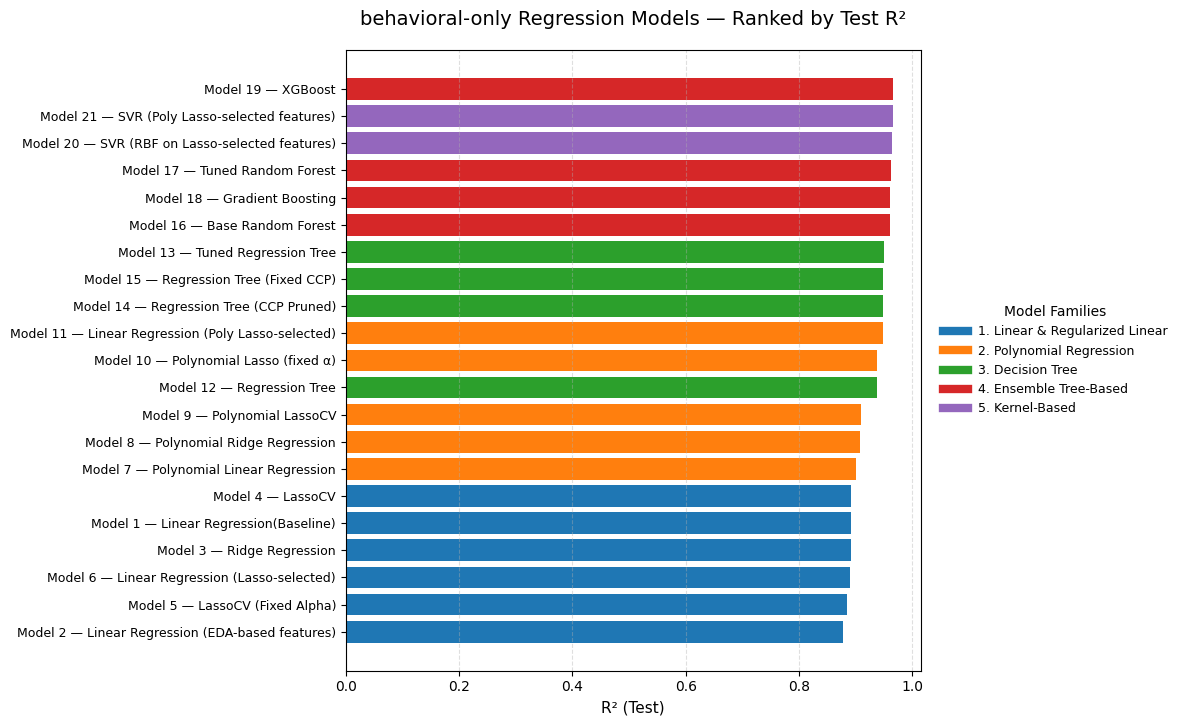

In [244]:

# ------------------------------------------------
# 1) Copy table (safe)
# ------------------------------------------------
df = df_behavioral.copy()

# ------------------------------------------------
# 2) Extract model number from Model name
# ------------------------------------------------
def extract_model_id(model_name):
    match = re.search(r"Model\s+(\d+)", model_name)
    return int(match.group(1)) if match else None

df["model_id"] = df["Model"].apply(extract_model_id)

# ------------------------------------------------
# 3) Assign model family
# ------------------------------------------------
def model_family(model_id):
    if model_id is None:
        return "Other"
    elif 1 <= model_id <= 6:
        return "1. Linear & Regularized Linear"
    elif 7 <= model_id <= 11:
        return "2. Polynomial Regression"
    elif 12 <= model_id <= 15:
        return "3. Decision Tree"
    elif 16 <= model_id <= 19:
        return "4. Ensemble Tree-Based"
    elif 20 <= model_id <= 21:
        return "5. Kernel-Based"
    else:
        return "Other"

df["Model_Family"] = df["model_id"].apply(model_family)

# ------------------------------------------------
# 4) Sort by R²_test
# ------------------------------------------------
df_sorted = (
    df
    .sort_values("R²_test", ascending=False)
    .reset_index(drop=True)
)

print("📋 behavioral-only Models — Sorted by R²_test")
display(df_sorted)

# ------------------------------------------------
# 5) Color mapping
# ------------------------------------------------
family_colors = {
    "1. Linear & Regularized Linear": "#1f77b4",
    "2. Polynomial Regression": "#ff7f0e",
    "3. Decision Tree": "#2ca02c",
    "4. Ensemble Tree-Based": "#d62728",
    "5. Kernel-Based": "#9467bd",
    "Other": "#7f7f7f"
}

bar_colors = df_sorted["Model_Family"].map(family_colors)
# ------------------------------------------------
# 6) Plot (ELEGANT FIX)
# ------------------------------------------------
n_models = len(df_sorted)
fig_height = max(5, n_models * 0.35)

plt.figure(figsize=(12, fig_height))

plt.barh(
    df_sorted["Model"],
    df_sorted["R²_test"],
    color=bar_colors
)

plt.gca().invert_yaxis()

plt.xlabel("R² (Test)", fontsize=11)
plt.ylabel("")
plt.title(
    "behavioral-only Regression Models — Ranked by Test R²",
    fontsize=14,
    pad=18
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.yticks(fontsize=9)
plt.xticks(fontsize=10)

# ------------------------------------------------
# 7) Legend (outside)
# ------------------------------------------------
legend_handles = [
    plt.Line2D([0], [0], color=color, lw=6, label=family)
    for family, color in family_colors.items()
    if family in df_sorted["Model_Family"].values
]

plt.legend(
    handles=legend_handles,
    title="Model Families",
    fontsize=9,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()


### 📋 Final Summary — Profile Regression Models
Models are ranked based on their out-of-sample performance (R² on the test set).
Clear performance differences can be observed across model families, with
ensemble and kernel-based models generally outperforming linear approaches,
while simpler models remain competitive given their interpretability and lower complexity.

#### Table 1 — Profile Regression Models in Order of Development

In [245]:
# ============================================
# 📋 Regression Models – Profile-only Summary
# ============================================

df_profile = pd.DataFrame(profile_log)

summary_cols = [
    "Model",
    "R²_train",
    "R²_test",
    "R²_CV",
    "MSE_test",
    "MSE_train",
    "Feature_count"
]

df_profile = df_profile[summary_cols]

print("📊 Profile-only Models Summary:")
display(df_profile)


📊 Profile-only Models Summary:


,Model,R²_train,R²_test,R²_CV,MSE_test,MSE_train,Feature_count
0,Model 1 — Linear Regression(Baseline),0.660,0.704,0.654,0.64,0.73,13
1,Model 2 — Linear Regression (EDA-based features),0.660,0.705,0.654,0.64,0.73,12
2,Model 3 — Ridge Regression,0.660,0.702,0.655,0.65,0.73,13
3,Model 4 — LassoCV,0.659,0.702,0.657,0.65,0.74,3
4,Model 5 — LassoCV (Fixed Alpha),0.658,0.701,0.657,0.65,0.74,3
5,Model 6 — Linear Regression (Lasso-selected),0.659,0.704,0.658,0.64,0.74,3
6,Model 7 — Polynomial Linear Regression,0.728,0.717,0.717,0.61,0.59,23
7,Model 8 — Polynomial Ridge Regression,0.728,0.718,0.717,0.61,0.59,23
8,Model 9 — Polynomial LassoCV,0.726,0.721,0.717,0.60,0.59,14
9,Model 10 — Polynomial Lasso (fixed α),0.713,0.716,0.709,0.62,0.62,6


#### Table 2 — Profile Regression Models Ranked by Test R²

📋 Profile-only Models — Sorted by R²_test


,Model,R²_train,R²_test,R²_CV,MSE_test,MSE_train,Feature_count,model_id,Model_Family
0,Model 21 — SVR (Poly Lasso-selected features),0.762,0.750,0.748,0.54,0.51,6,21,5. Kernel-Based
1,Model 20 — SVR (RBF on Lasso-selected features),0.761,0.742,0.749,0.56,0.52,4,20,5. Kernel-Based
2,Model 17 — Tuned Random Forest,0.842,0.741,0.739,0.56,0.34,13,17,4. Ensemble Tree-Based
3,Model 19 — XGBoost,0.779,0.740,0.742,0.56,0.48,13,19,4. Ensemble Tree-Based
4,Model 18 — Gradient Boosting,0.808,0.736,0.740,0.57,0.41,13,18,4. Ensemble Tree-Based
5,Model 16 — Base Random Forest,0.963,0.731,0.731,0.58,0.08,13,16,4. Ensemble Tree-Based
6,Model 9 — Polynomial LassoCV,0.726,0.721,0.717,0.60,0.59,14,9,2. Polynomial Regression
7,Model 13 — Tuned Regression Tree,0.755,0.719,0.721,0.61,0.53,13,13,3. Decision Tree
8,Model 8 — Polynomial Ridge Regression,0.728,0.718,0.717,0.61,0.59,23,8,2. Polynomial Regression
9,Model 7 — Polynomial Linear Regression,0.728,0.717,0.717,0.61,0.59,23,7,2. Polynomial Regression


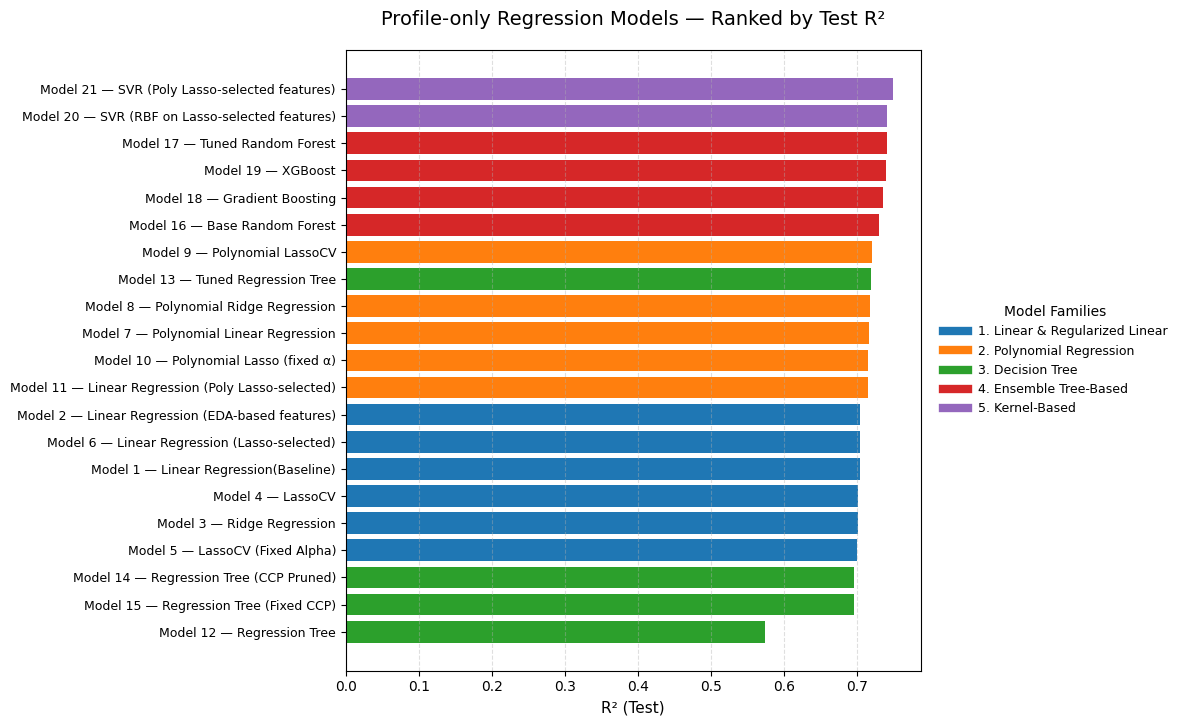

In [246]:

# ------------------------------------------------
# 1) Copy table (safe)
# ------------------------------------------------
df = df_profile.copy()

# ------------------------------------------------
# 2) Extract model number from Model name
# ------------------------------------------------
def extract_model_id(model_name):
    match = re.search(r"Model\s+(\d+)", model_name)
    return int(match.group(1)) if match else None

df["model_id"] = df["Model"].apply(extract_model_id)

# ------------------------------------------------
# 3) Assign model family
# ------------------------------------------------
def model_family(model_id):
    if model_id is None:
        return "Other"
    elif 1 <= model_id <= 6:
        return "1. Linear & Regularized Linear"
    elif 7 <= model_id <= 11:
        return "2. Polynomial Regression"
    elif 12 <= model_id <= 15:
        return "3. Decision Tree"
    elif 16 <= model_id <= 19:
        return "4. Ensemble Tree-Based"
    elif 20 <= model_id <= 21:
        return "5. Kernel-Based"
    else:
        return "Other"

df["Model_Family"] = df["model_id"].apply(model_family)

# ------------------------------------------------
# 4) Sort by R²_test
# ------------------------------------------------
df_sorted = (
    df
    .sort_values("R²_test", ascending=False)
    .reset_index(drop=True)
)

print("📋 Profile-only Models — Sorted by R²_test")
display(df_sorted)

# ------------------------------------------------
# 5) Color mapping
# ------------------------------------------------
family_colors = {
    "1. Linear & Regularized Linear": "#1f77b4",
    "2. Polynomial Regression": "#ff7f0e",
    "3. Decision Tree": "#2ca02c",
    "4. Ensemble Tree-Based": "#d62728",
    "5. Kernel-Based": "#9467bd",
    "Other": "#7f7f7f"
}

bar_colors = df_sorted["Model_Family"].map(family_colors)

# ------------------------------------------------
# 6) Plot (ELEGANT FIX)
# ------------------------------------------------
n_models = len(df_sorted)
fig_height = max(5, n_models * 0.35)

plt.figure(figsize=(12, fig_height))

plt.barh(
    df_sorted["Model"],
    df_sorted["R²_test"],
    color=bar_colors
)

plt.gca().invert_yaxis()

plt.xlabel("R² (Test)", fontsize=11)
plt.ylabel("")
plt.title(
    "Profile-only Regression Models — Ranked by Test R²",
    fontsize=14,
    pad=18
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.yticks(fontsize=9)
plt.xticks(fontsize=10)

# ------------------------------------------------
# 7) Legend (outside)
# ------------------------------------------------
legend_handles = [
    plt.Line2D([0], [0], color=color, lw=6, label=family)
    for family, color in family_colors.items()
    if family in df_sorted["Model_Family"].values
]

plt.legend(
    handles=legend_handles,
    title="Model Families",
    fontsize=9,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()
